# Classification Model - NYC Council Capital Budget Funding Level Prediction

This notebook implements multiple classification models to predict **Funding Levels** (low, mid-low, mid, mid-high, high) based on NYC Council Capital Budget data.

### Models Implemented (per Project Requirements):
1. **Logistic regression** — From Scratch (Softmax) + Sklearn
2. **Decision tree** — From Scratch + Sklearn
3. **Ensemble learning: Random Forest** — From Scratch + Sklearn
4. **Support vector machine** — From Scratch + Sklearn
5. **Dimensionality reduction for random forest/support vector machine** — PCA
6. **Unsupervised k-mean and agglomerative clustering** — From Scratch + Sklearn
7. **Perceptron & Single-layer perceptron (SLP)** — From Scratch + Sklearn
8. **Multi-layer perceptron (MLP)** — From Scratch + Sklearn
9. **A better and extracurricular classification model (mandatory): Gradient Boosting** — From Scratch + Sklearn

### Evaluation Metrics:
- Confusion Matrix, Accuracy, Precision, Recall (Sensitivity), Specificity, F1-Score
- ROC & AUC curves
- Loss / Accuracy performance curves

## Imports & Setup

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_fscore_support,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans as SklearnKMeans, AgglomerativeClustering
from sklearn.neural_network import MLPClassifier
from scipy.cluster.hierarchy import dendrogram, linkage

print("All imports successful.")

All imports successful.


## Data Loading & Exploration

In [57]:
df = pd.read_csv("../engineered_nyc.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11491, 21)


,Fiscal_Year,Borough,Award,Council_District_num,Sector_Community & Culture,Sector_Education,Sector_Environment,Sector_General Admin,Sector_Health & Human Svcs,Sector_Housing & Dev,...,Sector_Transportation,Categ_Arts & Culture,Categ_Community/Housing,Categ_Education,Categ_Healthcare,Categ_Infrastructure/Renovation,Categ_Parks & Recreation,Categ_Safety/Security,Categ_Technology,Other
0,2019,X,250000,16.0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
1,2019,K,3640000,37.0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0
2,2019,M,425000,5.0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3,2019,M,100000,5.0,0,1,0,0,0,0,...,0,0,0,1,0,1,1,0,0,0
4,2019,M,35000,5.0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,1,0


In [58]:
print("Missing values:")
print(df.isna().sum())
print(f"\nData types:\n{df.dtypes}")

Missing values:
Fiscal_Year                         0
Borough                             0
Award                               0
Council_District_num               26
Sector_Community & Culture          0
Sector_Education                    0
Sector_Environment                  0
Sector_General Admin                0
Sector_Health & Human Svcs          0
Sector_Housing & Dev                0
Sector_Public Safety                0
Sector_Transportation               0
Categ_Arts & Culture                0
Categ_Community/Housing             0
Categ_Education                     0
Categ_Healthcare                    0
Categ_Infrastructure/Renovation     0
Categ_Parks & Recreation            0
Categ_Safety/Security               0
Categ_Technology                    0
Other                               0
dtype: int64

Data types:
Fiscal_Year                          int64
Borough                                str
Award                                int64
Council_District_num           

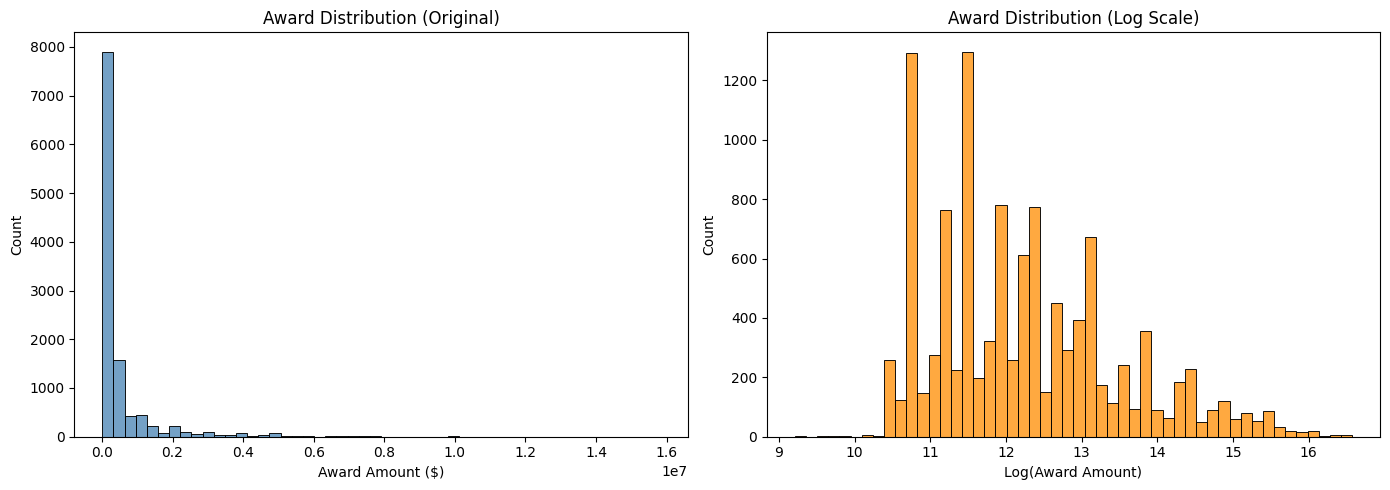

In [59]:
# Award distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Award'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Award Distribution (Original)')
axes[0].set_xlabel('Award Amount ($)')

sns.histplot(np.log1p(df['Award']), bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Award Distribution (Log Scale)')
axes[1].set_xlabel('Log(Award Amount)')
plt.tight_layout()
plt.show()

## Create Funding Level Labels (Target Variable)

We create 5 funding level bins (`low`, `mid-low`, `mid`, `mid-high`, `high`) based on the distribution of Award amounts **within each Fiscal Year**, so the classification is relative to each year's budget.

In [60]:
def create_funding_levels(df, award_col="Award", year_col="Fiscal_Year"):
    """
    Create funding level labels (low, mid-low, mid, mid-high, high)
    based on Award distribution within each Fiscal Year.
    """
    labels = ["low", "mid-low", "mid", "mid-high", "high"]

    def _per_year(group):
        if group[award_col].nunique() < 5:
            ranks = group[award_col].rank(method="first")
            group["Funding_Level"] = pd.qcut(
                ranks, q=min(5, len(group)),
                labels=labels[:min(5, len(group))]
            )
        else:
            ranks = group[award_col].rank(method="first")
            group["Funding_Level"] = pd.qcut(ranks, q=5, labels=labels)
        return group

    df = df.copy()
    df = df.dropna(subset=[award_col, year_col])
    # Preserve year_col: groupby can drop it in newer pandas
    saved_year = df[year_col].copy()
    df = df.groupby(year_col, group_keys=False).apply(_per_year)
    if year_col not in df.columns:
        df[year_col] = saved_year
    return df


df = create_funding_levels(df)
df = df.dropna(subset=["Funding_Level"])

print("Funding Level distribution:")
print(df["Funding_Level"].value_counts())

Funding Level distribution:
Funding_Level
low         2303
high        2298
mid-high    2297
mid-low     2297
mid         2296
Name: count, dtype: int64


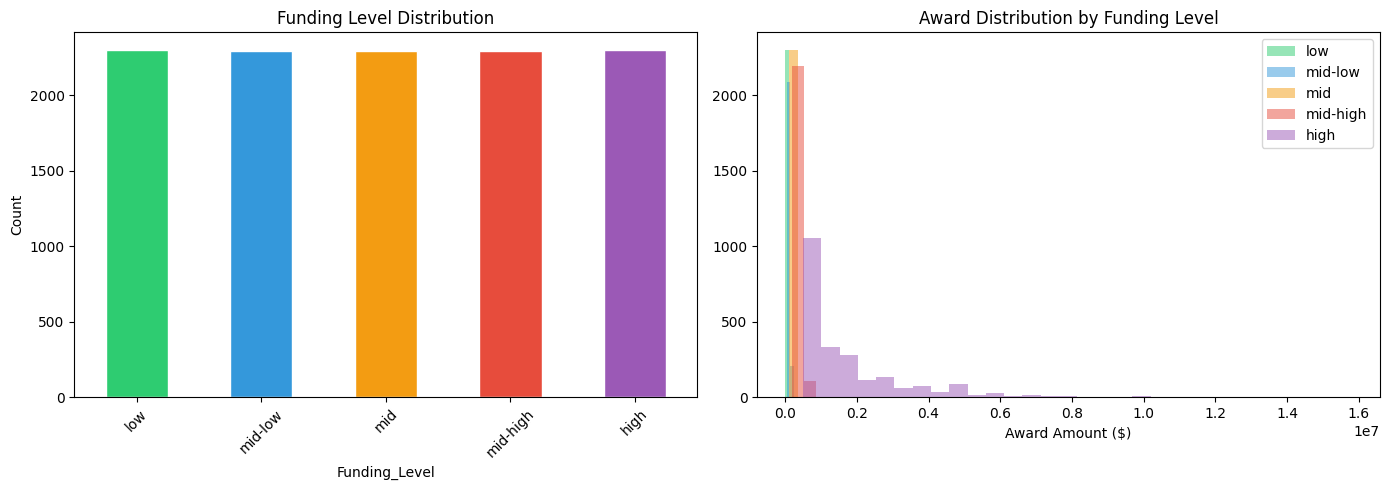

In [61]:
# Visualize Funding Level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["low", "mid-low", "mid", "mid-high", "high"]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']

df["Funding_Level"].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Funding Level Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(order, rotation=45)

for level, color in zip(order, colors):
    subset = df[df['Funding_Level'] == level]['Award']
    axes[1].hist(subset, bins=30, alpha=0.5, label=level, color=color)
axes[1].set_title('Award Distribution by Funding Level')
axes[1].set_xlabel('Award Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Feature Selection, Encoding & Train/Test Split

In [62]:
def encode_labels(y):
    """Convert Funding_Level strings to integers 0..K-1."""
    unique_labels = sorted(y.dropna().unique().tolist())
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}
    int_to_label = {idx: label for label, idx in label_to_int.items()}
    y_int = y.map(label_to_int).astype(int)
    return y_int, label_to_int, int_to_label


# Fix corrupted Council_District_num (NYC has 51 districts max)
df["Council_District_num"] = df["Council_District_num"].clip(upper=51)

# One-hot encode Borough if it's still a string column
if not pd.api.types.is_numeric_dtype(df["Borough"]):
    borough_dummies = pd.get_dummies(df["Borough"], prefix="Borough")
    df = pd.concat([df, borough_dummies], axis=1)

# Select feature columns
feature_cols = ["Fiscal_Year", "Council_District_num"]
sector_cols = [c for c in df.columns if c.startswith("Sector_")]
categ_cols = [c for c in df.columns if c.startswith("Categ_")]
borough_cols = [c for c in df.columns if c.startswith("Borough_")]
feature_cols.extend(sector_cols + categ_cols + borough_cols)
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy().fillna(0)
y_int, label_to_int, int_to_label = encode_labels(df["Funding_Level"])
class_names = [int_to_label[i] for i in sorted(int_to_label)]
num_classes = len(class_names)

print(f"Features used: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")
print(f"Classes: {label_to_int}")
print(f"Dataset size: {X.shape}")

Features used: 24
Feature list: ['Fiscal_Year', 'Council_District_num', 'Sector_Community & Culture', 'Sector_Education', 'Sector_Environment', 'Sector_General Admin', 'Sector_Health & Human Svcs', 'Sector_Housing & Dev', 'Sector_Public Safety', 'Sector_Transportation', 'Categ_Arts & Culture', 'Categ_Community/Housing', 'Categ_Education', 'Categ_Healthcare', 'Categ_Infrastructure/Renovation', 'Categ_Parks & Recreation', 'Categ_Safety/Security', 'Categ_Technology', 'Borough_A', 'Borough_K', 'Borough_M', 'Borough_Q', 'Borough_R', 'Borough_X']
Classes: {'high': 0, 'low': 1, 'mid': 2, 'mid-high': 3, 'mid-low': 4}
Dataset size: (11491, 24)


In [63]:
# Train/Test Split & Feature Scaling (Yeo-Johnson / generalized Box-Cox)
# Yeo-Johnson is a generalized Box-Cox that handles zero and negative values
# It transforms features to be more Gaussian-like, improving model performance
scaler = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = scaler.fit_transform(X.values)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_int.values,
    test_size=0.2, random_state=42, stratify=y_int.values
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (test):  {np.bincount(y_test)}")

Training set: 9192 samples
Test set:     2299 samples
Class distribution (train): [1838 1842 1837 1837 1838]
Class distribution (test):  [460 461 459 460 459]


## Helper Functions: Evaluation & Visualization

These helper functions will be reused across all models for consistent evaluation.

In [64]:
# Dictionary to store results for final benchmarking
results = {}


def evaluate_model(name, y_true, y_pred, y_proba=None, show_plots=True):
    """
    Comprehensive evaluation: Accuracy, Precision, Recall (Sensitivity),
    Specificity, F1, Confusion Matrix, ROC-AUC.
    """
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # Per-class metrics
    cm = confusion_matrix(y_true, y_pred)
    
    # Specificity & True Negative Rate (per class, then average)
    specificities = []
    for i in range(num_classes):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity)
    avg_specificity = np.mean(specificities)
    
    # ROC-AUC
    auc_score = None
    if y_proba is not None:
        try:
            y_test_bin = label_binarize(y_true, classes=list(range(num_classes)))
            auc_score = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        except Exception:
            auc_score = None
    
    # Store result
    results[name] = {
        'Accuracy': acc,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'Specificity (TNR)': avg_specificity,
        'F1-Score': f1,
        'ROC-AUC': auc_score
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Accuracy:              {acc:.4f}")
    print(f"  Precision (weighted):  {precision:.4f}")
    print(f"  Recall/Sensitivity:    {recall:.4f}")
    print(f"  Specificity (TNR):     {avg_specificity:.4f}")
    print(f"  F1-Score (weighted):   {f1:.4f}")
    if auc_score is not None:
        print(f"  ROC-AUC (macro):       {auc_score:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Confusion Matrix
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=axes[0], cmap='Blues', colorbar=False
        )
        axes[0].set_title(f'{name} - Confusion Matrix')
        
        # ROC Curves
        if y_proba is not None:
            y_test_bin = label_binarize(y_true, classes=list(range(num_classes)))
            for i in range(num_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                roc_auc_i = auc(fpr, tpr)
                axes[1].plot(fpr, tpr, label=f'{class_names[i]} (AUC={roc_auc_i:.2f})')
            axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
            axes[1].set_xlabel('False Positive Rate')
            axes[1].set_ylabel('True Positive Rate')
            axes[1].set_title(f'{name} - ROC Curves (One-vs-Rest)')
            axes[1].legend(fontsize=8)
        else:
            axes[1].text(0.5, 0.5, 'No probability\nestimates available',
                        ha='center', va='center', fontsize=14)
            axes[1].set_title(f'{name} - ROC Curves')
        
        plt.tight_layout()
        plt.show()
    
    return results[name]

==========

## 1. Logistic regression

==========

We implement multiclass logistic regression using both a **from-scratch Softmax** approach and **Sklearn's LogisticRegression**.

### 1.1 From Scratch (Softmax Regression)

The Softmax function generalizes binary logistic regression to K classes by computing:

$P(y = k | x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$

where $z_k = w_k^T x + b_k$

The loss function is the **cross-entropy loss**:

$L = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(p_{ik})$

In [65]:
class SoftmaxRegression:
    """
    Multiclass Logistic Regression (Softmax) — built from scratch.
    Uses gradient descent to minimize cross-entropy loss.
    """

    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.W = None
        self.b = None
        self.loss_history = []  # Track loss for performance curve

    @staticmethod
    def _softmax(Z):
        Z_shift = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    @staticmethod
    def _one_hot(y, num_classes):
        N = y.shape[0]
        one_hot = np.zeros((N, num_classes))
        one_hot[np.arange(N), y] = 1
        return one_hot

    def _cross_entropy_loss(self, probs, y_one_hot):
        N = probs.shape[0]
        # Clip to avoid log(0)
        log_probs = -np.log(np.clip(probs, 1e-12, 1.0))
        loss = np.sum(y_one_hot * log_probs) / N
        return loss

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        N, d = X.shape
        num_classes = len(np.unique(y))

        self.W = np.zeros((d, num_classes))
        self.b = np.zeros((1, num_classes))
        y_one_hot = self._one_hot(y, num_classes)
        self.loss_history = []

        for i in range(self.n_iters):
            logits = X.dot(self.W) + self.b
            probs = self._softmax(logits)

            # Track loss
            if i % 50 == 0:
                loss = self._cross_entropy_loss(probs, y_one_hot)
                self.loss_history.append(loss)

            grad_logits = (probs - y_one_hot) / N
            grad_W = X.T.dot(grad_logits)
            grad_b = np.sum(grad_logits, axis=0, keepdims=True)

            self.W -= self.lr * grad_W
            self.b -= self.lr * grad_b

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        logits = X.dot(self.W) + self.b
        return self._softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


  Softmax Regression (Scratch)
  Accuracy:              0.4093
  Precision (weighted):  0.3886
  Recall/Sensitivity:    0.4093
  Specificity (TNR):     0.8523
  F1-Score (weighted):   0.3849
  ROC-AUC (macro):       0.7319

Classification Report:
              precision    recall  f1-score   support

        high       0.49      0.61      0.54       460
         low       0.45      0.67      0.54       461
         mid       0.27      0.14      0.18       459
    mid-high       0.34      0.38      0.36       460
     mid-low       0.39      0.25      0.30       459

    accuracy                           0.41      2299
   macro avg       0.39      0.41      0.38      2299
weighted avg       0.39      0.41      0.38      2299



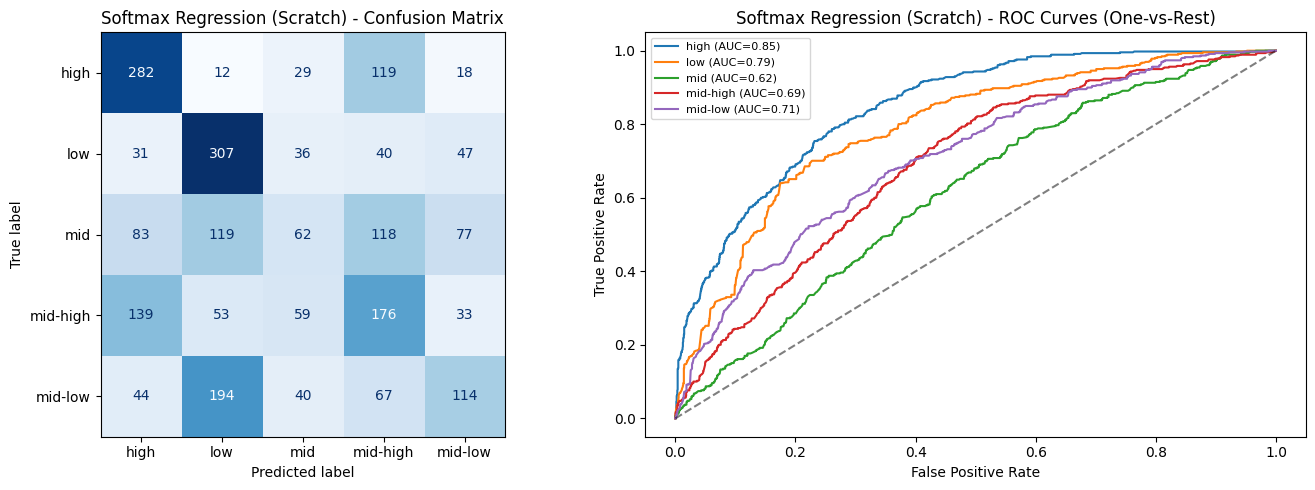

{'Accuracy': 0.40930839495432797,
 'Precision': 0.3885696803415877,
 'Recall (Sensitivity)': 0.40930839495432797,
 'Specificity (TNR)': np.float64(0.8523087091686972),
 'F1-Score': 0.38491400051576785,
 'ROC-AUC': 0.7319173581800723}

In [66]:
# Train Softmax Regression from scratch
softmax_model = SoftmaxRegression(lr=0.05, n_iters=5000)
softmax_model.fit(X_train, y_train)

y_pred_softmax = softmax_model.predict(X_test)
y_proba_softmax = softmax_model.predict_proba(X_test)

evaluate_model("Softmax Regression (Scratch)", y_test, y_pred_softmax, y_proba_softmax)

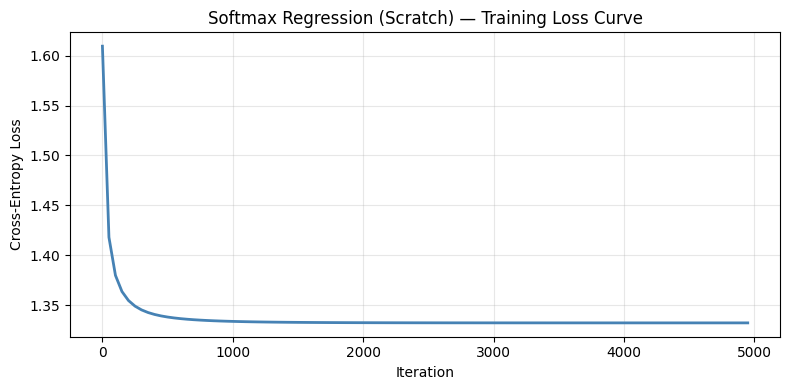

In [67]:
# Loss curve for Softmax (from scratch)
plt.figure(figsize=(8, 4))
plt.plot(range(0, len(softmax_model.loss_history) * 50, 50),
         softmax_model.loss_history, color='steelblue', linewidth=2)
plt.title('Softmax Regression (Scratch) — Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Logistic Regression — Sklearn


  Logistic Regression (Sklearn)
  Accuracy:              0.4093
  Precision (weighted):  0.3886
  Recall/Sensitivity:    0.4093
  Specificity (TNR):     0.8523
  F1-Score (weighted):   0.3849
  ROC-AUC (macro):       0.7319

Classification Report:
              precision    recall  f1-score   support

        high       0.49      0.61      0.54       460
         low       0.45      0.67      0.54       461
         mid       0.27      0.14      0.18       459
    mid-high       0.34      0.38      0.36       460
     mid-low       0.39      0.25      0.30       459

    accuracy                           0.41      2299
   macro avg       0.39      0.41      0.38      2299
weighted avg       0.39      0.41      0.38      2299



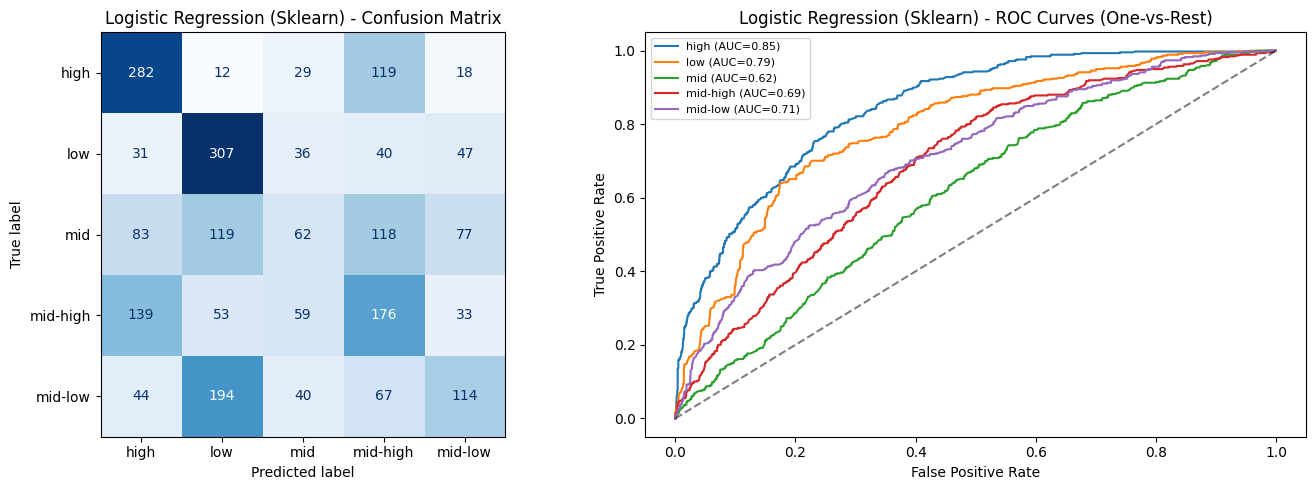

{'Accuracy': 0.40930839495432797,
 'Precision': 0.3885696803415877,
 'Recall (Sensitivity)': 0.40930839495432797,
 'Specificity (TNR)': np.float64(0.8523087091686972),
 'F1-Score': 0.38491400051576785,
 'ROC-AUC': 0.7319220726715656}

In [68]:
sk_logreg = LogisticRegression(
    solver='lbfgs', max_iter=300, C=0.5, random_state=42
)
sk_logreg.fit(X_train, y_train)

y_pred_sklr = sk_logreg.predict(X_test)
y_proba_sklr = sk_logreg.predict_proba(X_test)

evaluate_model("Logistic Regression (Sklearn)", y_test, y_pred_sklr, y_proba_sklr)

==========

## 2. Decision tree

==========

We implement a Decision Tree classifier both from scratch and using Sklearn.

### 2.1 From Scratch (Gini Impurity)

We build a Decision Tree using **Gini Impurity** as the splitting criterion:

$Gini(D) = 1 - \sum_{k=1}^{K} p_k^2$

where $p_k$ is the proportion of class $k$ in node $D$.

In [69]:
class DecisionTreeScratch:
    """
    Decision Tree Classifier built from scratch using Gini Impurity.
    """

    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value  # Class label for leaf nodes

    def __init__(self, max_depth=10, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.n_classes = None

    def _gini(self, y):
        """Calculate Gini Impurity."""
        if len(y) == 0:
            return 0
        counts = np.bincount(y, minlength=self.n_classes)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        """Find the best feature and threshold to split on."""
        best_gain = -1
        best_feature, best_threshold = None, None
        parent_gini = self._gini(y)
        n = len(y)

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            # Subsample thresholds for speed if many unique values
            if len(thresholds) > 50:
                thresholds = np.percentile(X[:, feature], np.linspace(0, 100, 50))

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                left_gini = self._gini(y[left_mask])
                right_gini = self._gini(y[right_mask])

                weighted_gini = (
                    np.sum(left_mask) / n * left_gini +
                    np.sum(right_mask) / n * right_gini
                )
                gain = parent_gini - weighted_gini

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        """Recursively build the decision tree."""
        # Stopping conditions
        if (depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(np.unique(y)) == 1):
            leaf_value = np.bincount(y, minlength=self.n_classes).argmax()
            return self.Node(value=leaf_value)

        feature, threshold = self._best_split(X, y)
        if feature is None:
            leaf_value = np.bincount(y, minlength=self.n_classes).argmax()
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return self.Node(feature=feature, threshold=threshold,
                         left=left_child, right=right_child)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y, dtype=int)
        self.n_classes = len(np.unique(y))
        self.root = self._build_tree(X, y)

    def _predict_one(self, x, node):
        """Predict class for a single sample."""
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.root) for x in X])


  Decision Tree (Scratch)
  Accuracy:              0.4676
  Precision (weighted):  0.4628
  Recall/Sensitivity:    0.4676
  Specificity (TNR):     0.8669
  F1-Score (weighted):   0.4633

Classification Report:
              precision    recall  f1-score   support

        high       0.53      0.57      0.55       460
         low       0.60      0.69      0.64       461
         mid       0.35      0.36      0.36       459
    mid-high       0.34      0.32      0.33       460
     mid-low       0.49      0.40      0.44       459

    accuracy                           0.47      2299
   macro avg       0.46      0.47      0.46      2299
weighted avg       0.46      0.47      0.46      2299



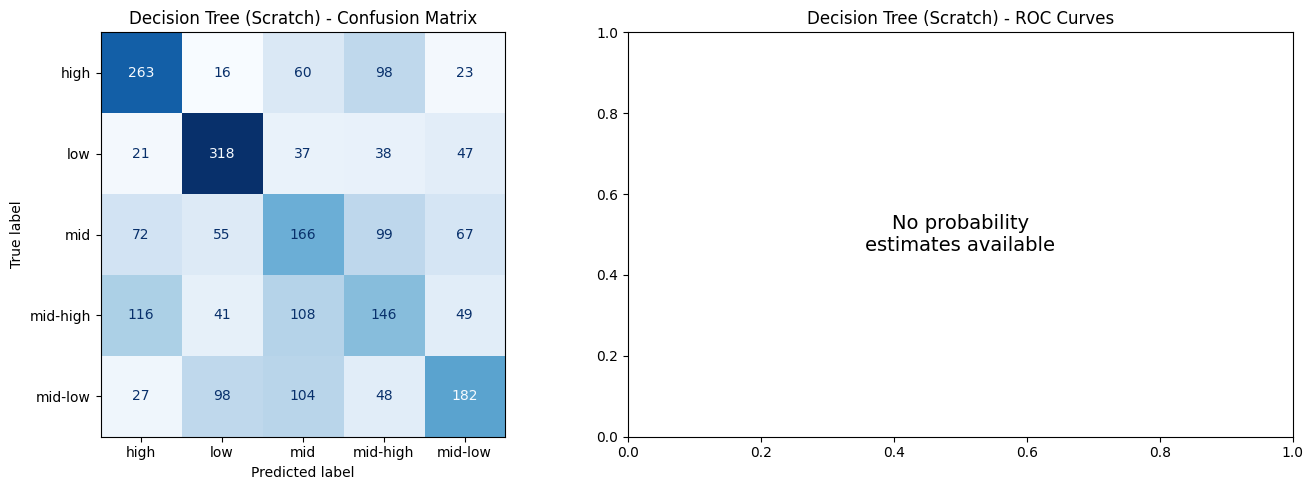

{'Accuracy': 0.4675946063505872,
 'Precision': 0.46283453216078446,
 'Recall (Sensitivity)': 0.4675946063505872,
 'Specificity (TNR)': np.float64(0.8669010078427991),
 'F1-Score': 0.4632603496483091,
 'ROC-AUC': None}

In [70]:
# Train Decision Tree from scratch
dt_scratch = DecisionTreeScratch(max_depth=20, min_samples_split=2)
dt_scratch.fit(X_train, y_train)

y_pred_dt_scratch = dt_scratch.predict(X_test)

evaluate_model("Decision Tree (Scratch)", y_test, y_pred_dt_scratch)

### 2.2 Decision Tree — Sklearn


  Decision Tree (Sklearn)
  Accuracy:              0.4424
  Precision (weighted):  0.4501
  Recall/Sensitivity:    0.4424
  Specificity (TNR):     0.8606
  F1-Score (weighted):   0.4420
  ROC-AUC (macro):       0.7579

Classification Report:
              precision    recall  f1-score   support

        high       0.59      0.66      0.62       460
         low       0.57      0.53      0.55       461
         mid       0.28      0.37      0.32       459
    mid-high       0.38      0.35      0.36       460
     mid-low       0.43      0.31      0.36       459

    accuracy                           0.44      2299
   macro avg       0.45      0.44      0.44      2299
weighted avg       0.45      0.44      0.44      2299



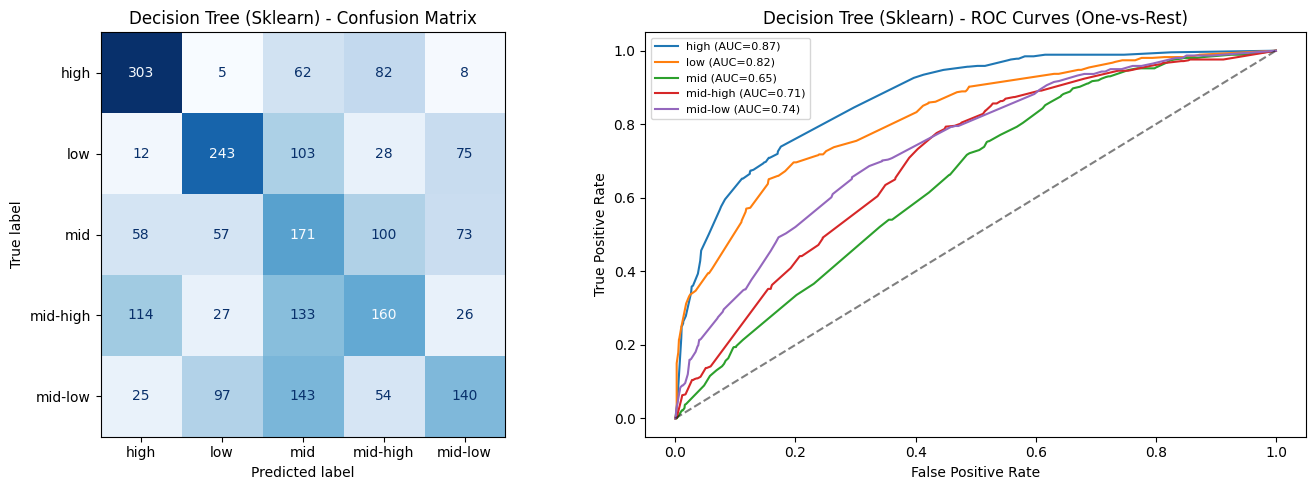

{'Accuracy': 0.4423662461939974,
 'Precision': 0.45008810773273417,
 'Recall (Sensitivity)': 0.4423662461939974,
 'Specificity (TNR)': np.float64(0.8606022175098763),
 'F1-Score': 0.4420064055792702,
 'ROC-AUC': 0.7579447534063447}

In [71]:
sk_dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)
sk_dt.fit(X_train, y_train)

y_pred_skdt = sk_dt.predict(X_test)
y_proba_skdt = sk_dt.predict_proba(X_test)

evaluate_model("Decision Tree (Sklearn)", y_test, y_pred_skdt, y_proba_skdt)

==========

## 3. Ensemble learning: Random Forest

==========

Random Forest is an ensemble of many Decision Trees, each trained on a random subset of the data (bagging) and features. The final prediction is the majority vote.

### 3.1 From Scratch (Bagging + Decision Trees)

In [72]:
class RandomForestScratch:
    """Random Forest classifier built from scratch using our DecisionTreeScratch."""

    def __init__(self, n_estimators=50, max_depth=10, min_samples_split=5,
                 max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.feature_indices = []
        self.n_classes = None

    def _get_max_features(self, n_features):
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(n_features)))
        elif self.max_features == 'log2':
            return max(1, int(np.log2(n_features)))
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        else:
            return n_features

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))
        max_feat = self._get_max_features(n_features)

        rng = np.random.RandomState(self.random_state)
        self.trees = []
        self.feature_indices = []

        for _ in range(self.n_estimators):
            # Bootstrap sample
            boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
            X_boot = X[boot_idx]
            y_boot = y[boot_idx]

            # Random feature subset
            feat_idx = np.sort(rng.choice(n_features, size=max_feat, replace=False))
            X_boot_sub = X_boot[:, feat_idx]

            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X_boot_sub, y_boot)

            self.trees.append(tree)
            self.feature_indices.append(feat_idx)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        all_preds = np.zeros((X.shape[0], self.n_classes))

        for tree, feat_idx in zip(self.trees, self.feature_indices):
            preds = tree.predict(X[:, feat_idx])
            for i, p in enumerate(preds):
                all_preds[i, p] += 1

        return np.argmax(all_preds, axis=1)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        all_preds = np.zeros((X.shape[0], self.n_classes))

        for tree, feat_idx in zip(self.trees, self.feature_indices):
            preds = tree.predict(X[:, feat_idx])
            for i, p in enumerate(preds):
                all_preds[i, p] += 1

        # Normalize to probabilities
        row_sums = all_preds.sum(axis=1, keepdims=True)
        return all_preds / row_sums


  Random Forest (Scratch)
  Accuracy:              0.3267
  Precision (weighted):  0.3981
  Recall/Sensitivity:    0.3267
  Specificity (TNR):     0.8316
  F1-Score (weighted):   0.2171
  ROC-AUC (macro):       0.7058

Classification Report:
              precision    recall  f1-score   support

        high       0.43      0.70      0.53       460
         low       0.27      0.85      0.41       461
         mid       0.35      0.03      0.05       459
    mid-high       0.44      0.03      0.06       460
     mid-low       0.50      0.02      0.03       459

    accuracy                           0.33      2299
   macro avg       0.40      0.33      0.22      2299
weighted avg       0.40      0.33      0.22      2299



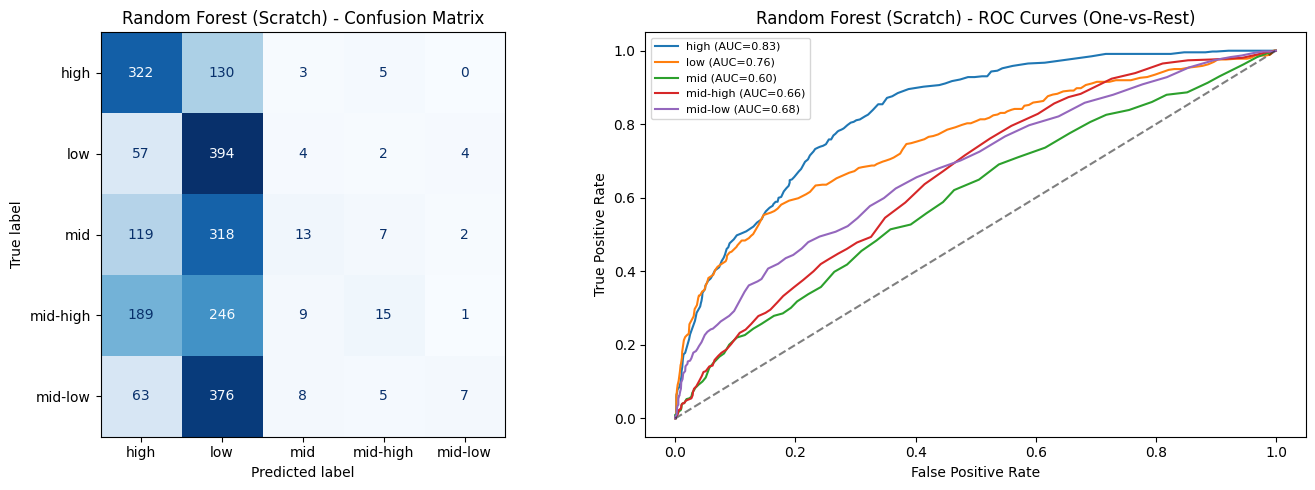

{'Accuracy': 0.3266637668551544,
 'Precision': 0.3981173205588962,
 'Recall (Sensitivity)': 0.3266637668551544,
 'Specificity (TNR)': np.float64(0.8315861547917682),
 'F1-Score': 0.2171024035899611,
 'ROC-AUC': 0.7058323298112027}

In [73]:
# Train Random Forest from scratch
rf_scratch = RandomForestScratch(
    n_estimators=200, max_depth=18, min_samples_split=2,
    max_features='sqrt', random_state=42
)
rf_scratch.fit(X_train, y_train)

y_pred_rf_scratch = rf_scratch.predict(X_test)
y_proba_rf_scratch = rf_scratch.predict_proba(X_test)

evaluate_model("Random Forest (Scratch)", y_test, y_pred_rf_scratch, y_proba_rf_scratch)

### 3.2 Using Sklearn


  Random Forest (Sklearn)
  Accuracy:              0.4489
  Precision (weighted):  0.4305
  Recall/Sensitivity:    0.4489
  Specificity (TNR):     0.8622
  F1-Score (weighted):   0.4290
  ROC-AUC (macro):       0.7651

Classification Report:
              precision    recall  f1-score   support

        high       0.56      0.69      0.62       460
         low       0.51      0.66      0.57       461
         mid       0.26      0.15      0.19       459
    mid-high       0.36      0.44      0.40       460
     mid-low       0.47      0.30      0.37       459

    accuracy                           0.45      2299
   macro avg       0.43      0.45      0.43      2299
weighted avg       0.43      0.45      0.43      2299



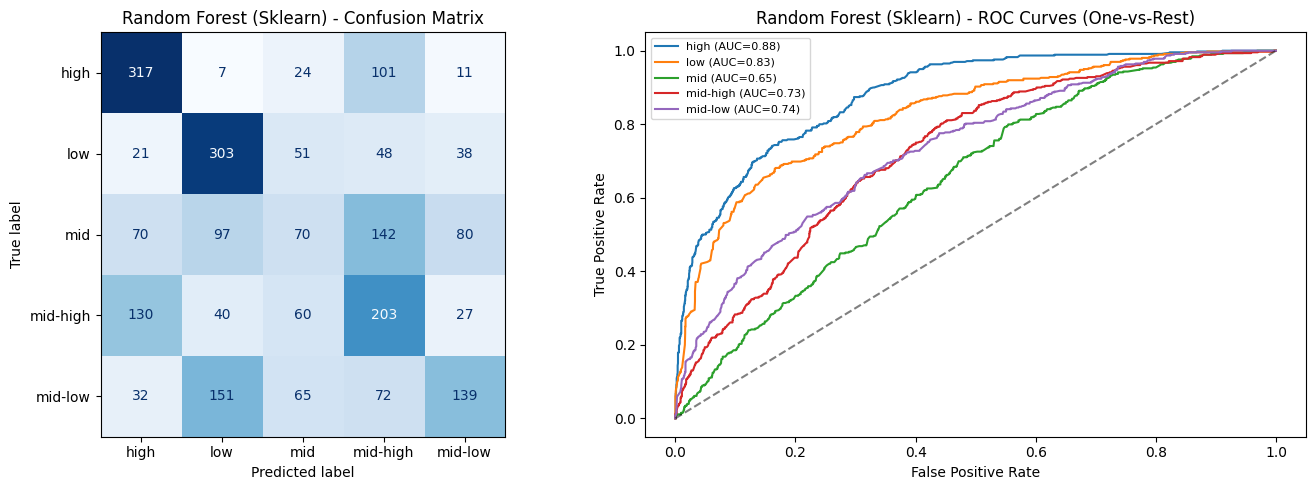

{'Accuracy': 0.4488908220965637,
 'Precision': 0.4304763296521557,
 'Recall (Sensitivity)': 0.4488908220965637,
 'Specificity (TNR)': np.float64(0.8622113080714302),
 'F1-Score': 0.42903705573372314,
 'ROC-AUC': 0.7650582440270528}

In [74]:
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)

evaluate_model("Random Forest (Sklearn)", y_test, y_pred_rf, y_proba_rf)

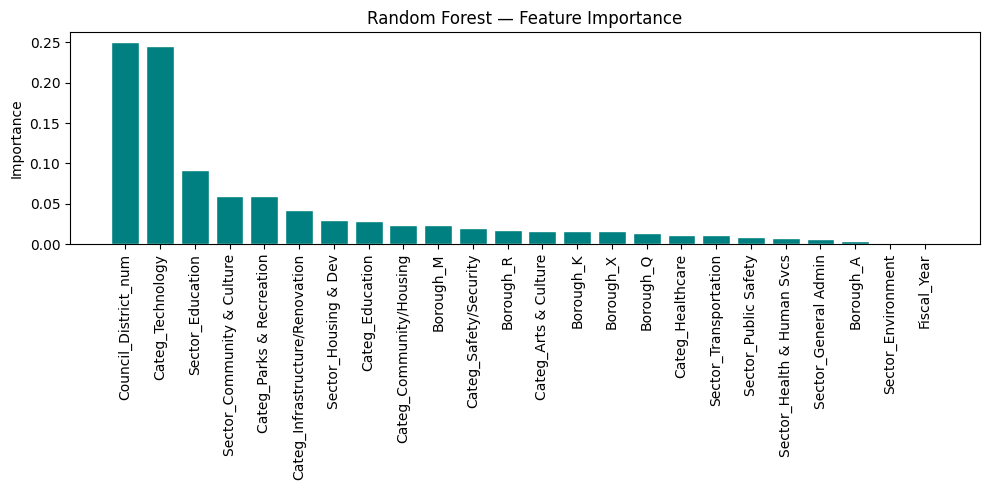

In [75]:
# Feature Importance from Random Forest
importances = rf_clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[sorted_idx], color='teal', edgecolor='white')
plt.xticks(range(len(importances)), [feature_cols[i] for i in sorted_idx], rotation=90)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

==========

## 4. Support vector machine

==========

### 4.1 From Scratch


  SVM From Scratch (OvR Linear)
  Accuracy:              0.3693
  Precision (weighted):  0.3642
  Recall/Sensitivity:    0.3693
  Specificity (TNR):     0.8423
  F1-Score (weighted):   0.3305
  ROC-AUC (macro):       0.6712

Classification Report:
              precision    recall  f1-score   support

        high       0.48      0.63      0.55       460
         low       0.44      0.65      0.52       461
         mid       0.22      0.14      0.17       459
    mid-high       0.43      0.07      0.12       460
     mid-low       0.25      0.35      0.29       459

    accuracy                           0.37      2299
   macro avg       0.36      0.37      0.33      2299
weighted avg       0.36      0.37      0.33      2299



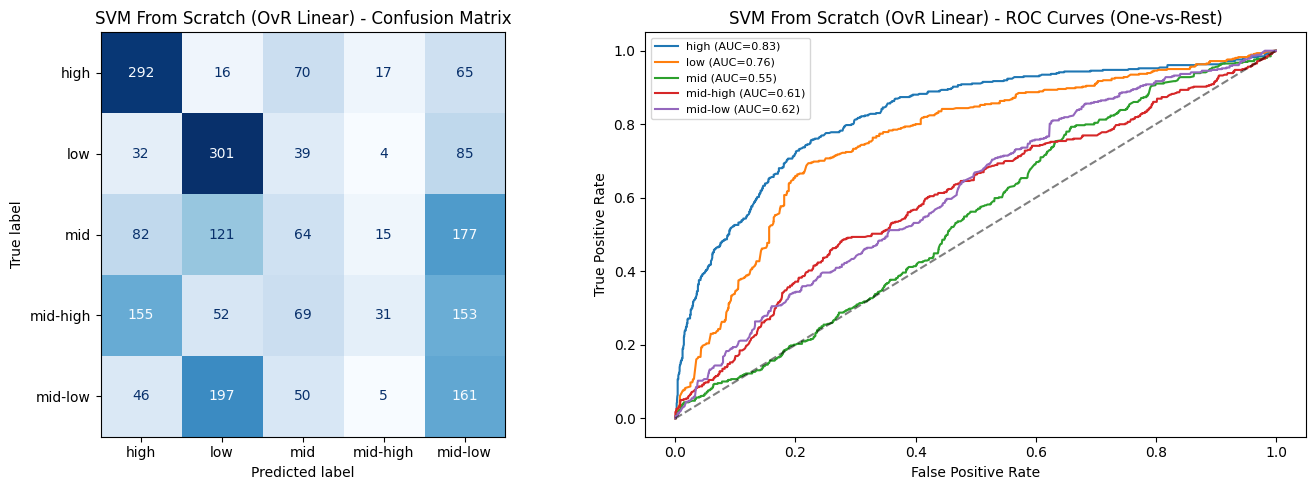

{'Accuracy': 0.36929099608525445,
 'Precision': 0.3641633023696783,
 'Recall (Sensitivity)': 0.36929099608525445,
 'Specificity (TNR)': np.float64(0.8423246081269496),
 'F1-Score': 0.3304557441138924,
 'ROC-AUC': 0.6712064085283431}

In [76]:
class SVMScratch:
    """
    Support Vector Machine — Multiclass via One-vs-Rest.
    Each binary classifier uses linear kernel with hinge loss + SGD.
    OvR scores are z-scored (calibrated on training data) so that
    classifiers with different scales are comparable for argmax / softmax.
    """

    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.classifiers = {}  # {class_label: (w, b)}

    def _fit_binary(self, X, y):
        """Train one binary SVM (y in {-1, +1})."""
        n_samples, n_features = X.shape
        w = np.zeros(n_features)
        b = 0.0
        rng = np.random.RandomState(42)
        for epoch in range(self.n_iters):
            indices = rng.permutation(n_samples)  # shuffle each epoch
            for i in indices:
                margin = y[i] * (X[i].dot(w) + b)
                if margin >= 1:
                    w -= self.lr * (2 * self.lambda_param * w)
                else:
                    w -= self.lr * (2 * self.lambda_param * w - y[i] * X[i])
                    b -= self.lr * (-y[i])
        return w, b

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for c in self.classes_:
            y_binary = np.where(y == c, 1, -1)
            w, b = self._fit_binary(X, y_binary)
            self.classifiers[c] = (w, b)
        # Calibrate: z-score each OvR classifier's output so all
        # scores are on the same scale (each binary SVM may learn
        # weights of very different magnitude → raw scores not comparable).
        raw = self._raw_scores(X)
        self._cal_mean = raw.mean(axis=0)
        self._cal_std = raw.std(axis=0)
        self._cal_std[self._cal_std < 1e-10] = 1.0
        return self

    def _raw_scores(self, X):
        """Un-calibrated OvR decision-function values."""
        scores = np.zeros((X.shape[0], len(self.classes_)))
        for idx, c in enumerate(self.classes_):
            w, b = self.classifiers[c]
            scores[:, idx] = X.dot(w) + b
        return scores

    def decision_function(self, X):
        """Calibrated decision-function values (z-scored per classifier)."""
        return (self._raw_scores(X) - self._cal_mean) / self._cal_std

    def predict(self, X):
        scores = self.decision_function(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        scores = self.decision_function(X)
        # softmax on calibrated scores → proper pseudo-probabilities
        exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)


# --- Train & Evaluate SVM From Scratch ---
# Use a subsample for speed (same pattern as other scratch models)
sample_idx = np.random.RandomState(42).choice(len(X_train), size=min(5000, len(X_train)), replace=False)
X_train_sample = X_train[sample_idx]
y_train_sample = y_train[sample_idx]

svm_scratch = SVMScratch(lr=0.001, lambda_param=0.001, n_iters=500)
svm_scratch.fit(X_train_sample, y_train_sample)

y_pred_svm_scratch = svm_scratch.predict(X_test)
y_proba_svm_scratch = svm_scratch.predict_proba(X_test)

evaluate_model("SVM From Scratch (OvR Linear)", y_test, y_pred_svm_scratch, y_proba_svm_scratch)

### 4.2 Using Sklearn


  SVM (Sklearn)
  Accuracy:              0.3971
  Precision (weighted):  0.3977
  Recall/Sensitivity:    0.3971
  Specificity (TNR):     0.8493
  F1-Score (weighted):   0.3448
  ROC-AUC (macro):       0.7029

Classification Report:
              precision    recall  f1-score   support

        high       0.44      0.65      0.52       460
         low       0.45      0.66      0.53       461
         mid       0.32      0.03      0.06       459
    mid-high       0.30      0.49      0.37       460
     mid-low       0.48      0.15      0.23       459

    accuracy                           0.40      2299
   macro avg       0.40      0.40      0.34      2299
weighted avg       0.40      0.40      0.34      2299



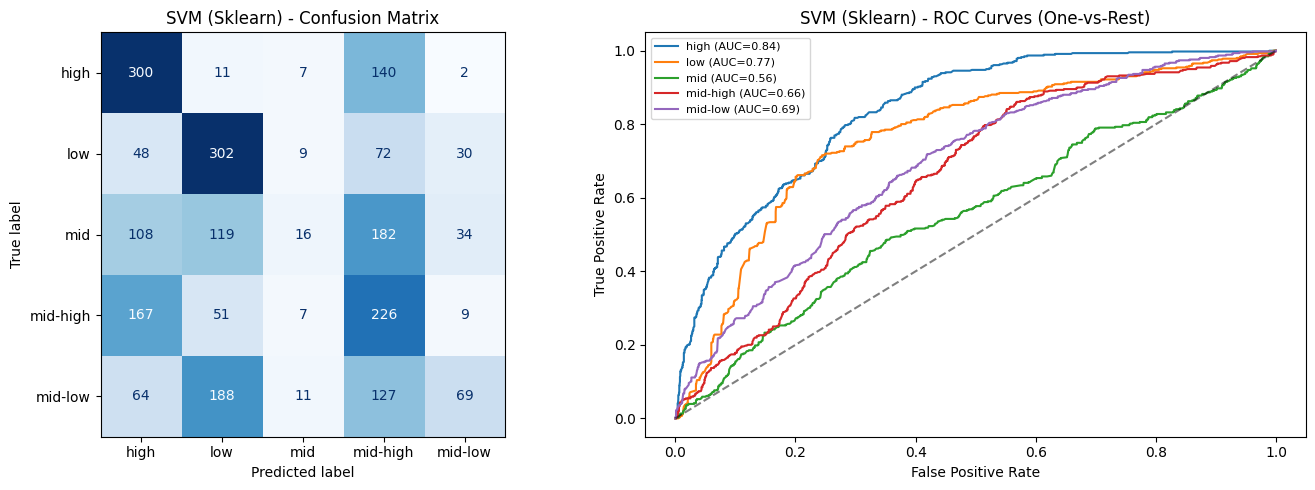

{'Accuracy': 0.39712918660287083,
 'Precision': 0.3977143225516119,
 'Recall (Sensitivity)': 0.39712918660287083,
 'Specificity (TNR)': np.float64(0.8492505141308252),
 'F1-Score': 0.34483086267902685,
 'ROC-AUC': 0.7029088312416102}

In [77]:
svm_clf = SVC(kernel='linear', C=0.5, probability=True, random_state=42)
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)

evaluate_model("SVM (Sklearn)", y_test, y_pred_svm, y_proba_svm)

==========

## 5. Dimensionality reduction for random forest/support vector machine

==========

We apply **Principal Component Analysis (PCA)** to reduce feature dimensions before training Random Forest and SVM, to see if reducing noise improves performance.

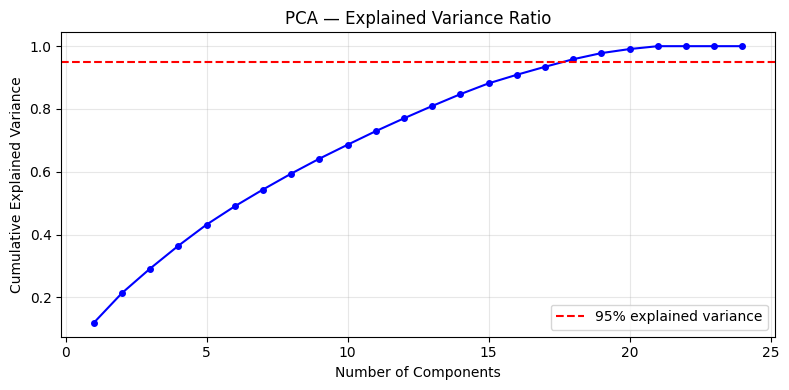


Using 18 PCA components (explains ≥95% variance)


In [78]:
# Determine number of components that explain 95% variance
pca_full = PCA().fit(X_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, 'bo-', markersize=4)
plt.axhline(0.95, color='r', linestyle='--', label='95% explained variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_components = np.argmax(cumvar >= 0.95) + 1
print(f"\nUsing {n_components} PCA components (explains ≥95% variance)")

In [79]:
# Apply PCA
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original features: {X_train.shape[1]} → PCA features: {X_train_pca.shape[1]}")

Original features: 24 → PCA features: 18



  Random Forest + PCA
  Accuracy:              0.4511
  Precision (weighted):  0.4466
  Recall/Sensitivity:    0.4511
  Specificity (TNR):     0.8628
  F1-Score (weighted):   0.4484
  ROC-AUC (macro):       0.7446

Classification Report:
              precision    recall  f1-score   support

        high       0.57      0.62      0.59       460
         low       0.60      0.60      0.60       461
         mid       0.31      0.29      0.30       459
    mid-high       0.36      0.37      0.36       460
     mid-low       0.40      0.37      0.39       459

    accuracy                           0.45      2299
   macro avg       0.45      0.45      0.45      2299
weighted avg       0.45      0.45      0.45      2299



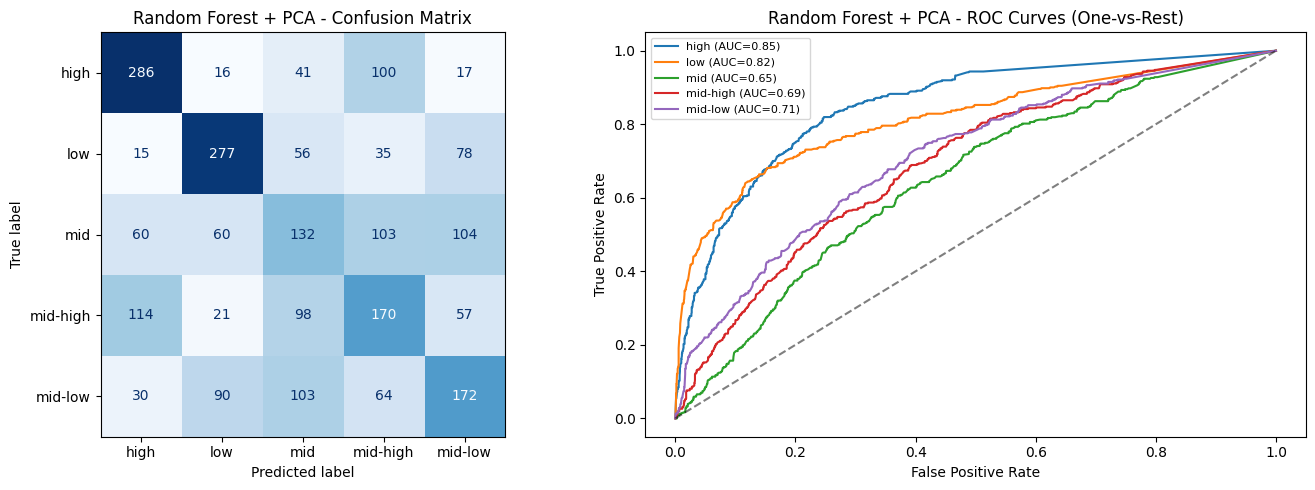

{'Accuracy': 0.4510656807307525,
 'Precision': 0.44661250057312324,
 'Recall (Sensitivity)': 0.4510656807307525,
 'Specificity (TNR)': np.float64(0.8627731751967016),
 'F1-Score': 0.44840940781517075,
 'ROC-AUC': 0.7445525154602841}

In [80]:
# Random Forest with PCA
rf_pca = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca = rf_pca.predict(X_test_pca)
y_proba_rf_pca = rf_pca.predict_proba(X_test_pca)

evaluate_model("Random Forest + PCA", y_test, y_pred_rf_pca, y_proba_rf_pca)


  SVM + PCA
  Accuracy:              0.4197
  Precision (weighted):  0.4027
  Recall/Sensitivity:    0.4197
  Specificity (TNR):     0.8549
  F1-Score (weighted):   0.3996
  ROC-AUC (macro):       0.7266

Classification Report:
              precision    recall  f1-score   support

        high       0.47      0.64      0.54       460
         low       0.49      0.63      0.55       461
         mid       0.28      0.15      0.20       459
    mid-high       0.34      0.39      0.36       460
     mid-low       0.43      0.29      0.34       459

    accuracy                           0.42      2299
   macro avg       0.40      0.42      0.40      2299
weighted avg       0.40      0.42      0.40      2299



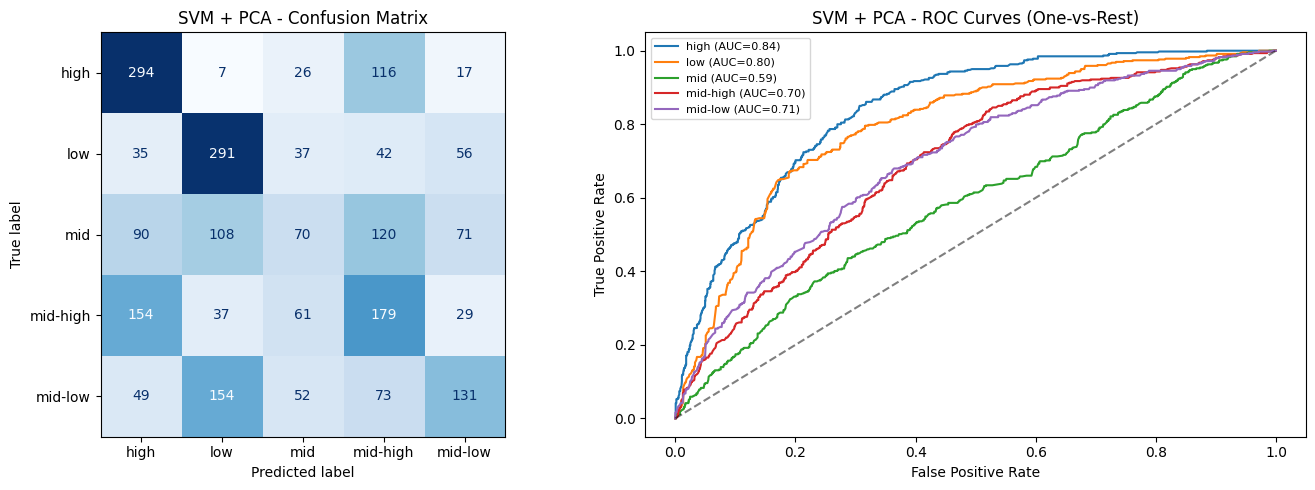

{'Accuracy': 0.4197477163984341,
 'Precision': 0.4027391062497521,
 'Recall (Sensitivity)': 0.4197477163984341,
 'Specificity (TNR)': np.float64(0.8549236746713348),
 'F1-Score': 0.39959961577695674,
 'ROC-AUC': 0.7265803481989994}

In [81]:
# SVM with PCA
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train)

y_pred_svm_pca = svm_pca.predict(X_test_pca)
y_proba_svm_pca = svm_pca.predict_proba(X_test_pca)

evaluate_model("SVM + PCA", y_test, y_pred_svm_pca, y_proba_svm_pca)

==========

## 6. Unsupervised k-mean and agglomerative clustering

==========

Unsupervised methods discover natural groupings in the feature space without using labels. We apply both **K-Means** and **Agglomerative (Hierarchical) Clustering**, then compare cluster assignments with true funding levels.

### 6.1 K-Means Clustering (From Scratch + Sklearn)

In [82]:
class KMeansScratch:

    def __init__(self, n_clusters=5, max_iters=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    def fit(self, X):
        np.random.seed(self.random_state)
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]

        # Initialize centroids randomly from data points
        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[indices].copy()

        for _ in range(self.max_iters):
            # Assign each point to nearest centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            # Update centroids
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.sum(labels == k) > 0
                else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            # Check convergence
            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        self.labels_ = labels
        self.inertia_ = np.sum((X - self.centroids[labels]) ** 2)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

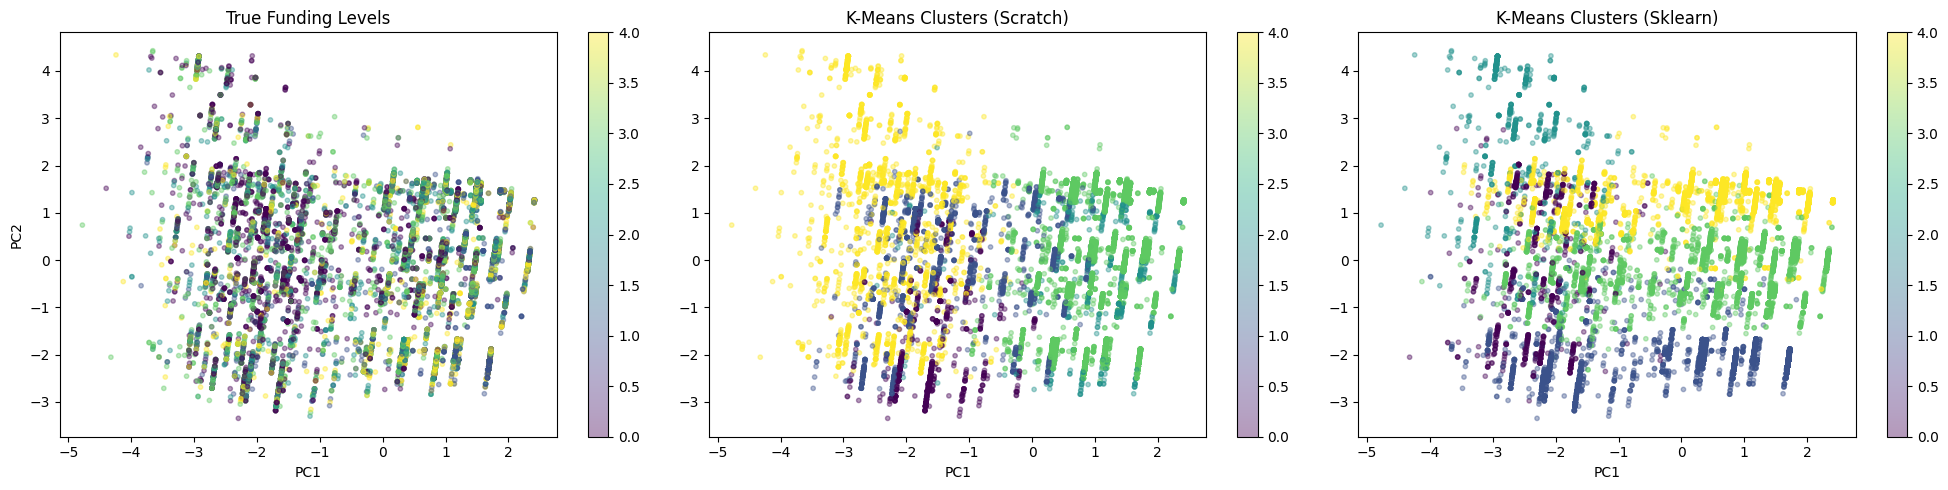

K-Means (Scratch) Inertia: 208389.88
K-Means (Sklearn) Inertia: 194749.23


In [83]:
# K-Means from scratch
kmeans_scratch = KMeansScratch(n_clusters=5, max_iters=300, random_state=42)
kmeans_scratch.fit(X_scaled)

# K-Means sklearn
kmeans_sk = SklearnKMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_sk.fit(X_scaled)

# Visualize clusters using PCA for 2D projection
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# True labels
scatter0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_int.values, cmap='viridis', alpha=0.4, s=10)
axes[0].set_title('True Funding Levels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter0, ax=axes[0])

# K-Means Scratch
scatter1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_scratch.labels_, cmap='viridis', alpha=0.4, s=10)
axes[1].set_title('K-Means Clusters (Scratch)')
axes[1].set_xlabel('PC1')
plt.colorbar(scatter1, ax=axes[1])

# K-Means Sklearn
scatter2 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_sk.labels_, cmap='viridis', alpha=0.4, s=10)
axes[2].set_title('K-Means Clusters (Sklearn)')
axes[2].set_xlabel('PC1')
plt.colorbar(scatter2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"K-Means (Scratch) Inertia: {kmeans_scratch.inertia_:.2f}")
print(f"K-Means (Sklearn) Inertia: {kmeans_sk.inertia_:.2f}")

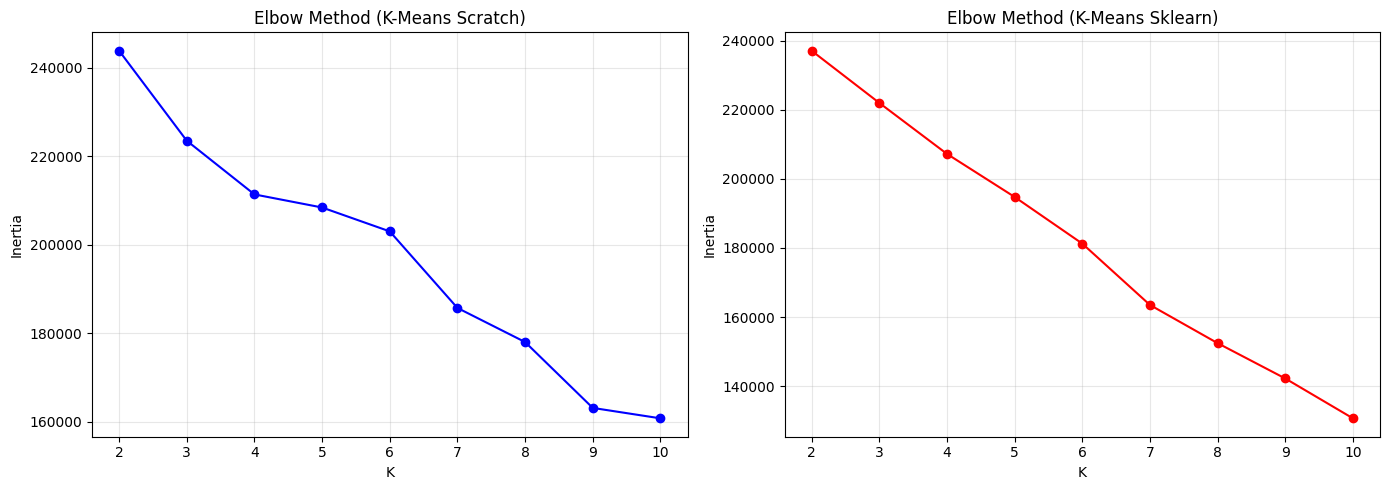

In [84]:
# Elbow method to find optimal K
inertias_scratch = []
inertias_sk = []
K_range = range(2, 11)

for k in K_range:
    km_s = KMeansScratch(n_clusters=k, random_state=42)
    km_s.fit(X_scaled)
    inertias_scratch.append(km_s.inertia_)
    
    km_sk = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    km_sk.fit(X_scaled)
    inertias_sk.append(km_sk.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias_scratch, 'bo-')
axes[0].set_title('Elbow Method (K-Means Scratch)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, inertias_sk, 'ro-')
axes[1].set_title('Elbow Method (K-Means Sklearn)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Inertia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Agglomerative Clustering

Agglomerative (hierarchical) clustering merges the closest clusters iteratively (bottom-up). We visualize using a dendrogram.

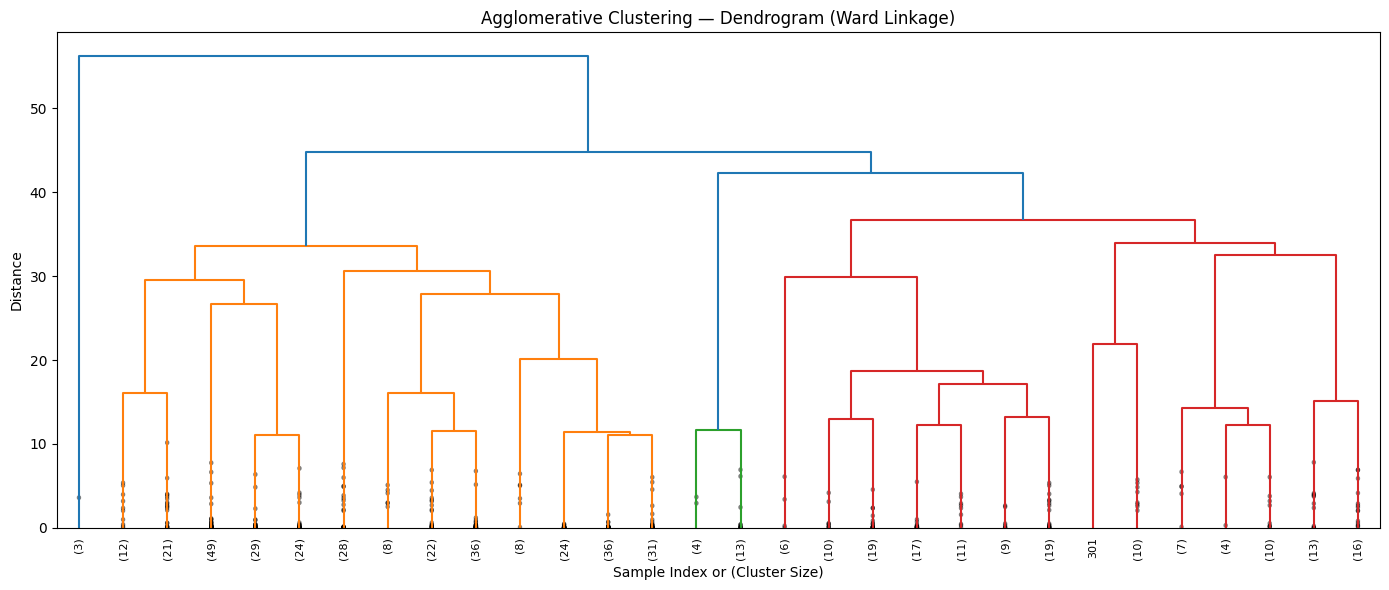

In [85]:
# Use a random subset for dendrogram visualization (full dataset is too large)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(500, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

# Dendrogram
linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=8, show_contracted=True)
plt.title('Agglomerative Clustering — Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

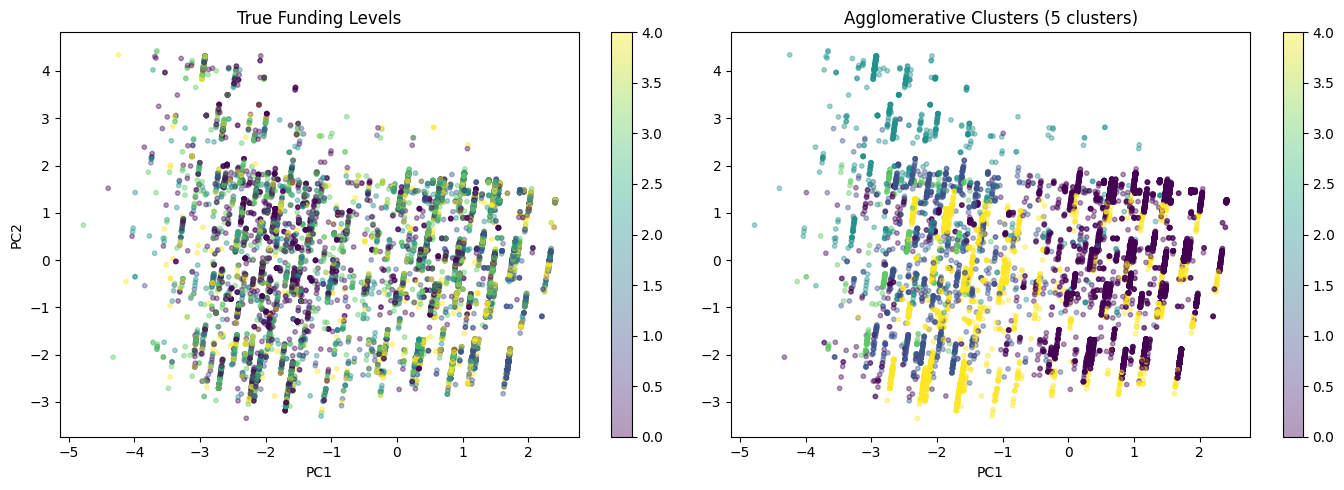

In [86]:
# Agglomerative clustering with 5 clusters
agg_clf = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg_clf.fit_predict(X_scaled)

# Compare with true labels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_int.values, cmap='viridis', alpha=0.4, s=10)
axes[0].set_title('True Funding Levels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter0, ax=axes[0])

scatter1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels, cmap='viridis', alpha=0.4, s=10)
axes[1].set_title('Agglomerative Clusters (5 clusters)')
axes[1].set_xlabel('PC1')
plt.colorbar(scatter1, ax=axes[1])

plt.tight_layout()
plt.show()

==========

## 7. Perceptron & Single-layer perceptron (SLP)

==========

The Perceptron is a single-layer linear classifier. For multiclass, we use a **one-vs-rest** approach. Each perceptron learns a binary decision boundary for one class.

### 7.1 Perceptron / SLP — From Scratch

In [87]:
class PerceptronScratch:

    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.biases = None
        self.n_classes = None
        self.accuracy_history = []

    def _step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))

        # One weight vector per class (OvR)
        self.weights = np.zeros((self.n_classes, n_features))
        self.biases = np.zeros(self.n_classes)
        self.accuracy_history = []

        for epoch in range(self.n_iters):
            for cls in range(self.n_classes):
                # Binary labels for this class
                y_binary = (y == cls).astype(int)

                linear_output = X.dot(self.weights[cls]) + self.biases[cls]
                y_pred = self._step_function(linear_output)

                # Update rule
                error = y_binary - y_pred
                self.weights[cls] += self.lr * X.T.dot(error) / n_samples
                self.biases[cls] += self.lr * np.sum(error) / n_samples

            # Track accuracy
            if epoch % 50 == 0:
                y_pred_all = self.predict(X)
                acc = np.mean(y_pred_all == y)
                self.accuracy_history.append(acc)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        # Score for each class
        scores = X.dot(self.weights.T) + self.biases
        return np.argmax(scores, axis=1)


  Perceptron / SLP (Scratch)
  Accuracy:              0.3271
  Precision (weighted):  0.2975
  Recall/Sensitivity:    0.3271
  Specificity (TNR):     0.8318
  F1-Score (weighted):   0.2469

Classification Report:
              precision    recall  f1-score   support

        high       0.44      0.70      0.54       460
         low       0.12      0.03      0.04       461
         mid       0.25      0.07      0.10       459
    mid-high       0.41      0.08      0.14       460
     mid-low       0.28      0.76      0.41       459

    accuracy                           0.33      2299
   macro avg       0.30      0.33      0.25      2299
weighted avg       0.30      0.33      0.25      2299



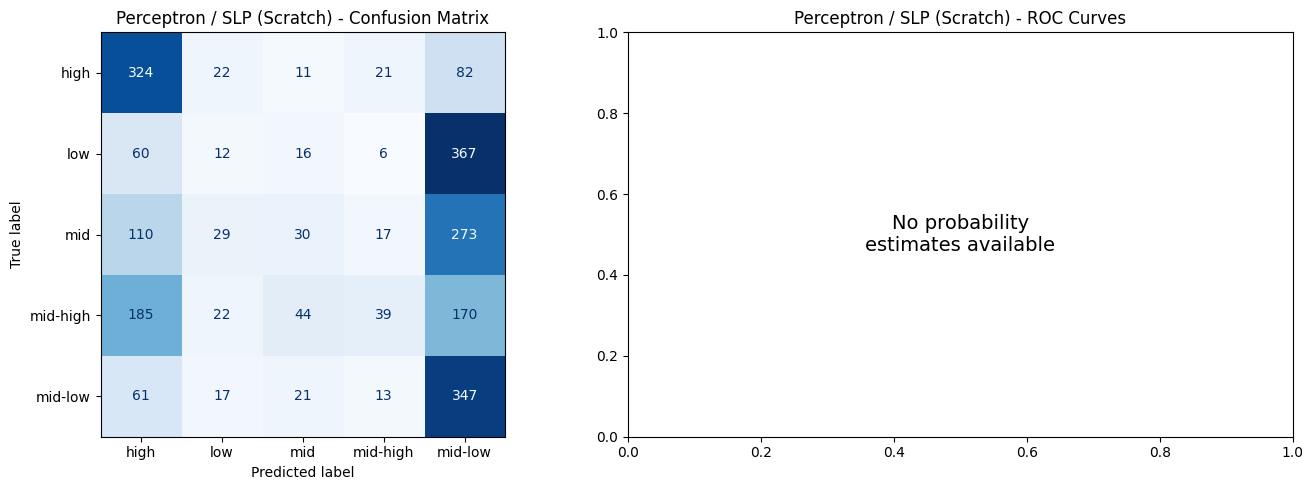

{'Accuracy': 0.3270987385819922,
 'Precision': 0.2974920351396011,
 'Recall (Sensitivity)': 0.3270987385819922,
 'Specificity (TNR)': np.float64(0.8318092241806431),
 'F1-Score': 0.24688385320818568,
 'ROC-AUC': None}

In [88]:
# Train Perceptron from scratch
perceptron_scratch = PerceptronScratch(lr=0.01, n_iters=2000)
perceptron_scratch.fit(X_train, y_train)

y_pred_perceptron = perceptron_scratch.predict(X_test)

evaluate_model("Perceptron / SLP (Scratch)", y_test, y_pred_perceptron)

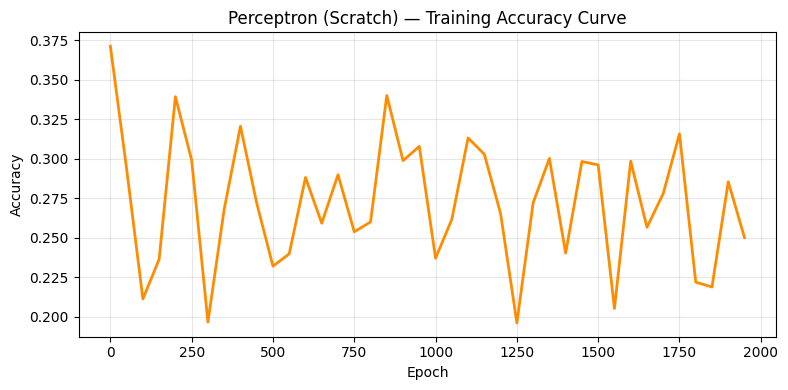

In [89]:
# Perceptron accuracy curve
plt.figure(figsize=(8, 4))
plt.plot(range(0, len(perceptron_scratch.accuracy_history) * 50, 50),
         perceptron_scratch.accuracy_history, color='darkorange', linewidth=2)
plt.title('Perceptron (Scratch) — Training Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Perceptron — Sklearn


  Perceptron (Sklearn)
  Accuracy:              0.3023
  Precision (weighted):  0.3041
  Recall/Sensitivity:    0.3023
  Specificity (TNR):     0.8256
  F1-Score (weighted):   0.3009

Classification Report:
              precision    recall  f1-score   support

        high       0.27      0.35      0.31       460
         low       0.41      0.40      0.41       461
         mid       0.21      0.17      0.19       459
    mid-high       0.28      0.30      0.29       460
     mid-low       0.36      0.29      0.32       459

    accuracy                           0.30      2299
   macro avg       0.30      0.30      0.30      2299
weighted avg       0.30      0.30      0.30      2299



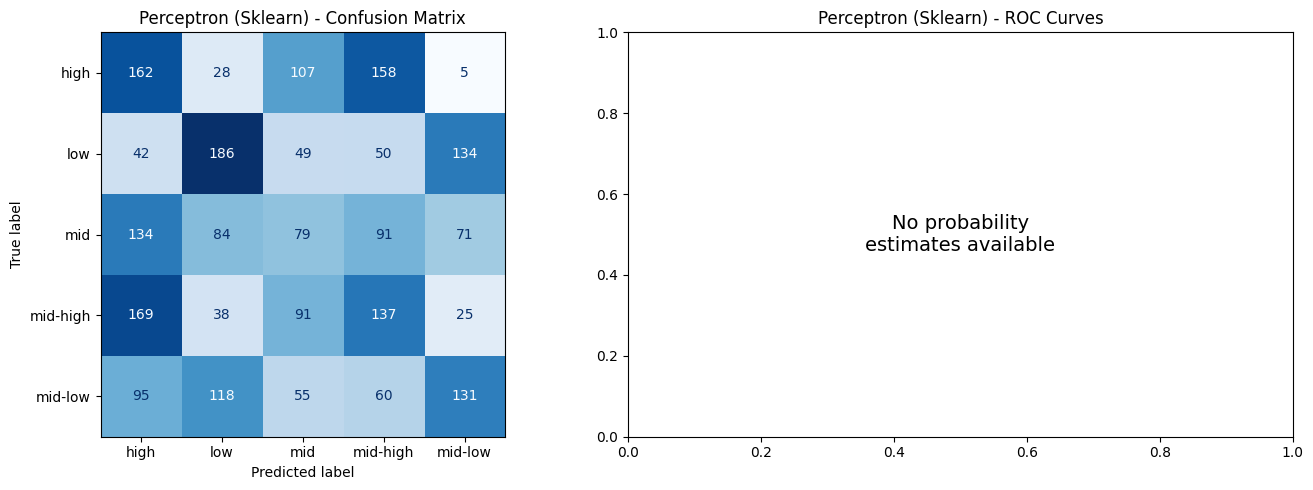

{'Accuracy': 0.3023053501522401,
 'Precision': 0.3041199573859224,
 'Recall (Sensitivity)': 0.3023053501522401,
 'Specificity (TNR)': np.float64(0.8255732503711062),
 'F1-Score': 0.3008725206905642,
 'ROC-AUC': None}

In [90]:
# Sklearn Perceptron for comparison
sk_perceptron = Perceptron(max_iter=100, eta0=0.01, random_state=42)
sk_perceptron.fit(X_train, y_train)

y_pred_sk_perceptron = sk_perceptron.predict(X_test)

evaluate_model("Perceptron (Sklearn)", y_test, y_pred_sk_perceptron)

==========

## 8. Multi-layer perceptron (MLP)

==========

### 8.1 MLP — From Scratch

We implement a Multi-Layer Perceptron with one hidden layer using:
- **ReLU** activation in the hidden layer
- **Softmax** activation in the output layer
- **Cross-entropy loss**
- **Backpropagation** for gradient computation

In [91]:
class MLPScratch:
    """
    Multi-Layer Perceptron with one hidden layer — built from scratch.
    Architecture: Input → Hidden (ReLU) → Output (Softmax)
    """

    def __init__(self, hidden_size=64, lr=0.01, n_iters=1000):
        self.hidden_size = hidden_size
        self.lr = lr
        self.n_iters = n_iters
        self.loss_history = []
        self.accuracy_history = []

    @staticmethod
    def _relu(Z):
        return np.maximum(0, Z)

    @staticmethod
    def _relu_deriv(Z):
        return (Z > 0).astype(float)

    @staticmethod
    def _softmax(Z):
        Z_shift = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    @staticmethod
    def _one_hot(y, num_classes):
        N = y.shape[0]
        oh = np.zeros((N, num_classes))
        oh[np.arange(N), y] = 1
        return oh

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        N, d = X.shape
        K = len(np.unique(y))

        # He initialization
        np.random.seed(42)
        self.W1 = np.random.randn(d, self.hidden_size) * np.sqrt(2.0 / d)
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, K) * np.sqrt(2.0 / self.hidden_size)
        self.b2 = np.zeros((1, K))

        y_oh = self._one_hot(y, K)
        self.loss_history = []
        self.accuracy_history = []

        for i in range(self.n_iters):
            # Forward pass
            Z1 = X.dot(self.W1) + self.b1
            A1 = self._relu(Z1)
            Z2 = A1.dot(self.W2) + self.b2
            A2 = self._softmax(Z2)  # probabilities

            # Cross-entropy loss
            loss = -np.mean(np.sum(y_oh * np.log(np.clip(A2, 1e-12, 1.0)), axis=1))

            # Backpropagation
            dZ2 = (A2 - y_oh) / N
            dW2 = A1.T.dot(dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = dZ2.dot(self.W2.T)
            dZ1 = dA1 * self._relu_deriv(Z1)
            dW1 = X.T.dot(dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update weights
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1

            if i % 50 == 0:
                self.loss_history.append(loss)
                acc = np.mean(np.argmax(A2, axis=1) == y)
                self.accuracy_history.append(acc)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        Z1 = X.dot(self.W1) + self.b1
        A1 = self._relu(Z1)
        Z2 = A1.dot(self.W2) + self.b2
        return self._softmax(Z2)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [93]:
# Train MLP from scratch
mlp_scratch = MLPScratch(hidden_size=256, lr=0.01, n_iters=5000)
mlp_scratch.fit(X_train, y_train)

y_pred_mlp = mlp_scratch.predict(X_test)
y_proba_mlp = mlp_scratch.predict_proba(X_test)

evaluate_model("MLP (Scratch)", y_test, y_pred_mlp, y_proba_mlp)

KeyboardInterrupt: 

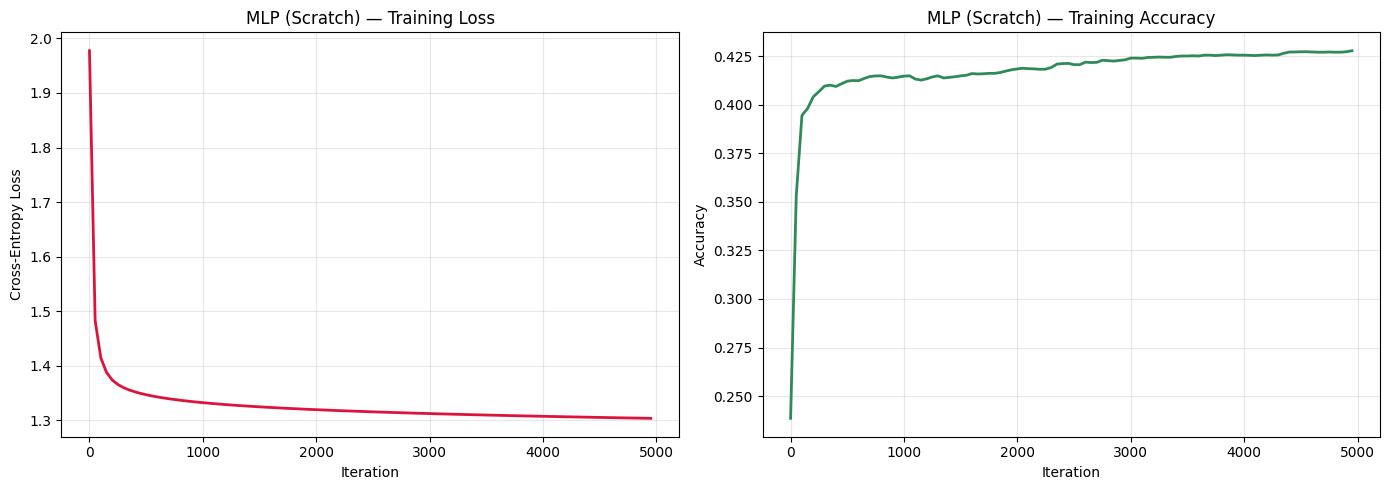

In [ ]:
# MLP Loss & Accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = range(0, len(mlp_scratch.loss_history) * 50, 50)
axes[0].plot(iters, mlp_scratch.loss_history, color='crimson', linewidth=2)
axes[0].set_title('MLP (Scratch) — Training Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, mlp_scratch.accuracy_history, color='seagreen', linewidth=2)
axes[1].set_title('MLP (Scratch) — Training Accuracy')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2 Multi-Layer Perceptron — Sklearn


  MLP (Sklearn)
  Accuracy:              0.4263
  Precision (weighted):  0.4139
  Recall/Sensitivity:    0.4263
  Specificity (TNR):     0.8566
  F1-Score (weighted):   0.4051
  ROC-AUC (macro):       0.7411

Classification Report:
              precision    recall  f1-score   support

        high       0.51      0.63      0.57       460
         low       0.46      0.66      0.54       461
         mid       0.28      0.18      0.22       459
    mid-high       0.36      0.43      0.39       460
     mid-low       0.45      0.23      0.30       459

    accuracy                           0.43      2299
   macro avg       0.41      0.43      0.40      2299
weighted avg       0.41      0.43      0.41      2299



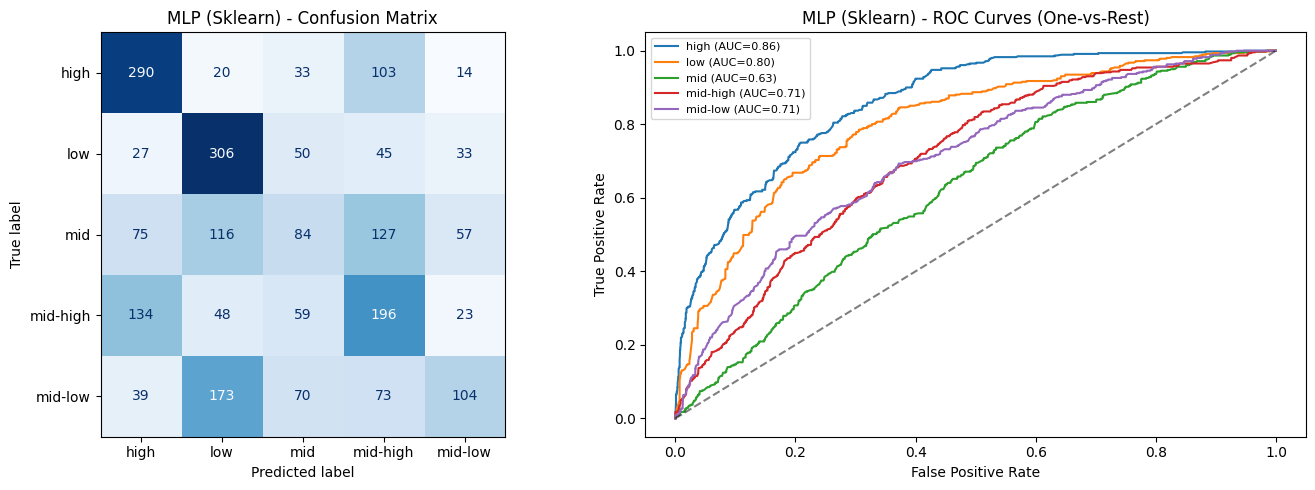

{'Accuracy': 0.42627229230100044,
 'Precision': 0.4138829173480864,
 'Recall (Sensitivity)': 0.42627229230100044,
 'Specificity (TNR)': np.float64(0.856551387304908),
 'F1-Score': 0.40513341049112755,
 'ROC-AUC': 0.7410875155935585}

In [ ]:
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(64,), activation='relu',
    max_iter=300, alpha=0.01, random_state=42
)
sk_mlp.fit(X_train, y_train)

y_pred_sk_mlp = sk_mlp.predict(X_test)
y_proba_sk_mlp = sk_mlp.predict_proba(X_test)

evaluate_model("MLP (Sklearn)", y_test, y_pred_sk_mlp, y_proba_sk_mlp)

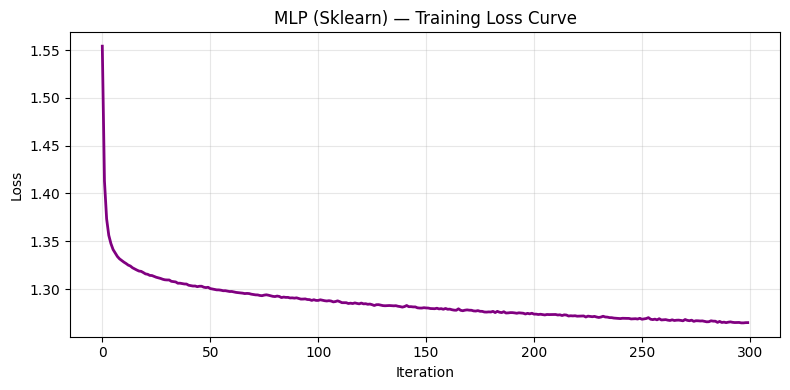

In [ ]:
# Sklearn MLP loss curve
plt.figure(figsize=(8, 4))
plt.plot(sk_mlp.loss_curve_, color='purple', linewidth=2)
plt.title('MLP (Sklearn) — Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

==========

## 9. A better and extracurricular classification model (mandatory)

==========

We choose **Gradient Boosting** as our extracurricular model. It is an advanced ensemble method that builds trees **sequentially**, where each new tree corrects the errors of the previous ones.

### 9.1 Gradient Boosting — From Scratch

We implement a simple version from scratch using one-vs-rest with decision tree stumps.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

class GradientBoostingClassifierScratch:

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = {}  # dict of class → list of trees
        self.n_classes = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.n_classes = len(np.unique(y))
        N = X.shape[0]

        # Initialize raw scores at 0
        raw_scores = {cls: np.zeros(N) for cls in range(self.n_classes)}
        self.trees = {cls: [] for cls in range(self.n_classes)}
        self.loss_history = []

        for i in range(self.n_estimators):
            total_loss = 0
            for cls in range(self.n_classes):
                # Binary target for this class
                y_binary = (y == cls).astype(float)

                # Current probabilities
                probs = self._sigmoid(raw_scores[cls])

                # Pseudo-residuals (negative gradient of log loss)
                residuals = y_binary - probs

                # Fit a regression tree to residuals
                tree = DecisionTreeRegressor(
                    max_depth=self.max_depth, random_state=self.random_state
                )
                tree.fit(X, residuals)

                # Update raw scores
                raw_scores[cls] += self.learning_rate * tree.predict(X)
                self.trees[cls].append(tree)

                # Log loss
                probs_clipped = np.clip(probs, 1e-12, 1 - 1e-12)
                total_loss += -np.mean(
                    y_binary * np.log(probs_clipped) +
                    (1 - y_binary) * np.log(1 - probs_clipped)
                )

            if i % 10 == 0:
                self.loss_history.append(total_loss / self.n_classes)

    def _predict_raw(self, X):
        X = np.asarray(X, dtype=float)
        N = X.shape[0]
        raw_scores = np.zeros((N, self.n_classes))
        for cls in range(self.n_classes):
            for tree in self.trees[cls]:
                raw_scores[:, cls] += self.learning_rate * tree.predict(X)
        return raw_scores

    def predict_proba(self, X):
        raw = self._predict_raw(X)
        # Apply softmax to get multiclass probabilities
        raw_shift = raw - np.max(raw, axis=1, keepdims=True)
        exp_raw = np.exp(raw_shift)
        return exp_raw / np.sum(exp_raw, axis=1, keepdims=True)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


  Gradient Boosting (Scratch)
  Accuracy:              0.4458
  Precision (weighted):  0.4337
  Recall/Sensitivity:    0.4458
  Specificity (TNR):     0.8615
  F1-Score (weighted):   0.4345
  ROC-AUC (macro):       0.7731

Classification Report:
              precision    recall  f1-score   support

        high       0.57      0.66      0.61       460
         low       0.53      0.62      0.57       461
         mid       0.31      0.22      0.25       459
    mid-high       0.35      0.43      0.39       460
     mid-low       0.42      0.31      0.35       459

    accuracy                           0.45      2299
   macro avg       0.43      0.45      0.43      2299
weighted avg       0.43      0.45      0.43      2299



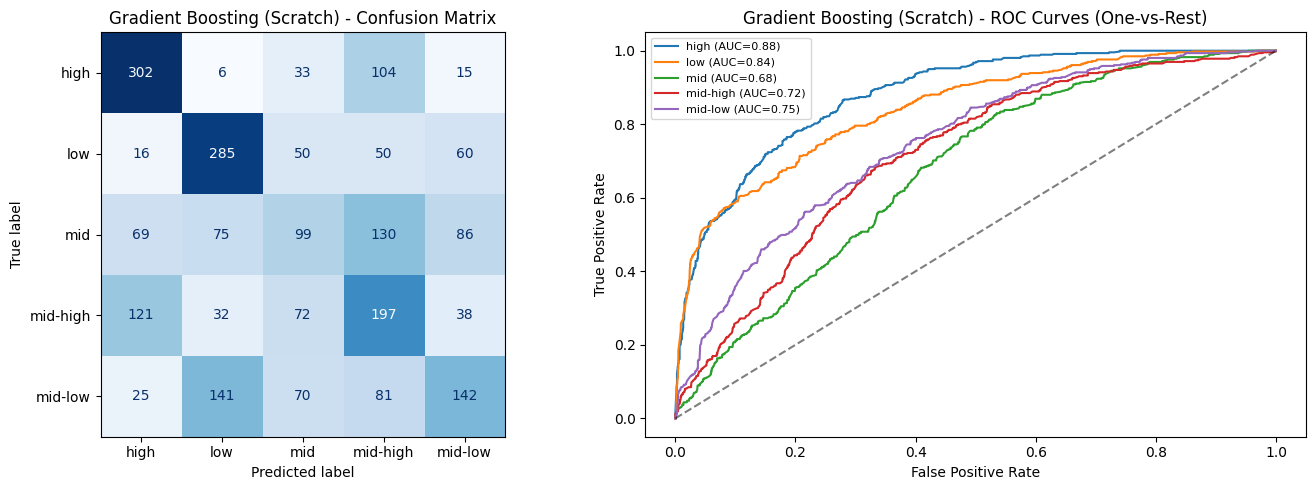

{'Accuracy': 0.44584602000869944,
 'Precision': 0.4336790941837808,
 'Recall (Sensitivity)': 0.44584602000869944,
 'Specificity (TNR)': np.float64(0.8614564699395124),
 'F1-Score': 0.4345024391071151,
 'ROC-AUC': 0.7731119139452021}

In [ ]:
# Train Gradient Boosting from scratch
gb_scratch = GradientBoostingClassifierScratch(
    n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42
)
gb_scratch.fit(X_train, y_train)

y_pred_gb = gb_scratch.predict(X_test)
y_proba_gb = gb_scratch.predict_proba(X_test)

evaluate_model("Gradient Boosting (Scratch)", y_test, y_pred_gb, y_proba_gb)

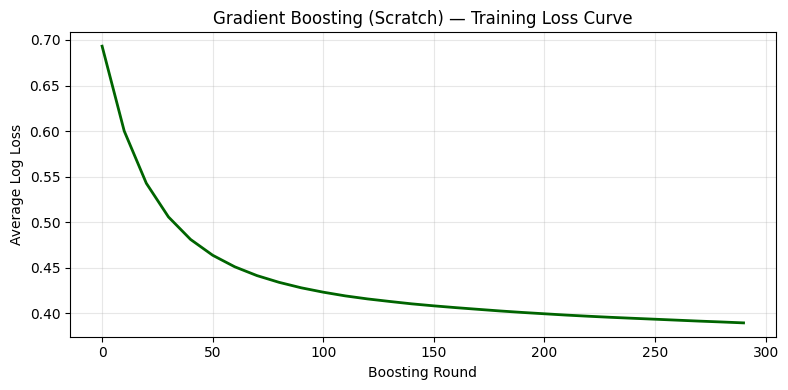

In [ ]:
# Loss curve for Gradient Boosting (scratch)
plt.figure(figsize=(8, 4))
plt.plot(range(0, len(gb_scratch.loss_history) * 10, 10),
         gb_scratch.loss_history, color='darkgreen', linewidth=2)
plt.title('Gradient Boosting (Scratch) — Training Loss Curve')
plt.xlabel('Boosting Round')
plt.ylabel('Average Log Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Gradient Boosting — Sklearn


  Gradient Boosting (Sklearn)
  Accuracy:              0.4324
  Precision (weighted):  0.4134
  Recall/Sensitivity:    0.4324
  Specificity (TNR):     0.8581
  F1-Score (weighted):   0.4139
  ROC-AUC (macro):       0.7541

Classification Report:
              precision    recall  f1-score   support

        high       0.53      0.68      0.59       460
         low       0.47      0.57      0.52       461
         mid       0.28      0.14      0.19       459
    mid-high       0.36      0.43      0.39       460
     mid-low       0.43      0.34      0.38       459

    accuracy                           0.43      2299
   macro avg       0.41      0.43      0.41      2299
weighted avg       0.41      0.43      0.41      2299



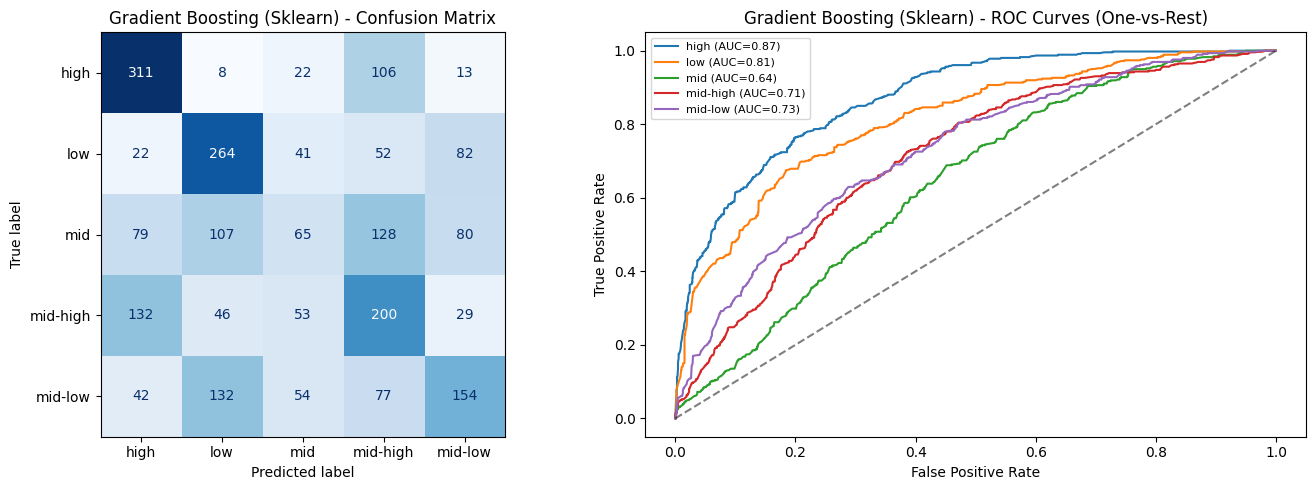

{'Accuracy': 0.432361896476729,
 'Precision': 0.4134160379744791,
 'Recall (Sensitivity)': 0.432361896476729,
 'Specificity (TNR)': np.float64(0.8580798095122107),
 'F1-Score': 0.4138853105795767,
 'ROC-AUC': 0.7541376882393784}

In [ ]:
# Sklearn Gradient Boosting for comparison
sk_gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42
)
sk_gb.fit(X_train, y_train)

y_pred_sk_gb = sk_gb.predict(X_test)
y_proba_sk_gb = sk_gb.predict_proba(X_test)

evaluate_model("Gradient Boosting (Sklearn)", y_test, y_pred_sk_gb, y_proba_sk_gb)

## Model Comparison & Benchmarking

We compare all supervised classification models side-by-side on all evaluation metrics.

In [ ]:
# Build comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "=" * 80)
print("  MODEL BENCHMARKING — ALL CLASSIFICATION MODELS")
print("=" * 80)
print(results_df.to_string())


  MODEL BENCHMARKING — ALL CLASSIFICATION MODELS
                               Accuracy  Precision  Recall (Sensitivity)  Specificity (TNR)  F1-Score   ROC-AUC
Decision Tree (Scratch)        0.460200   0.449288              0.460200           0.865052  0.451428       NaN
Random Forest + PCA            0.448021   0.441189              0.448021           0.862011  0.443831  0.746282
Gradient Boosting (Scratch)    0.445846   0.433679              0.445846           0.861456  0.434502  0.773112
Decision Tree (Sklearn)        0.438452   0.441417              0.438452           0.859620  0.436128  0.755256
Random Forest (Sklearn)        0.437582   0.424450              0.437582           0.859381  0.418148  0.757447
Gradient Boosting (Sklearn)    0.432362   0.413416              0.432362           0.858080  0.413885  0.754138
MLP (Sklearn)                  0.426272   0.413883              0.426272           0.856551  0.405133  0.741088
MLP (Scratch)                  0.402784   0.376049    

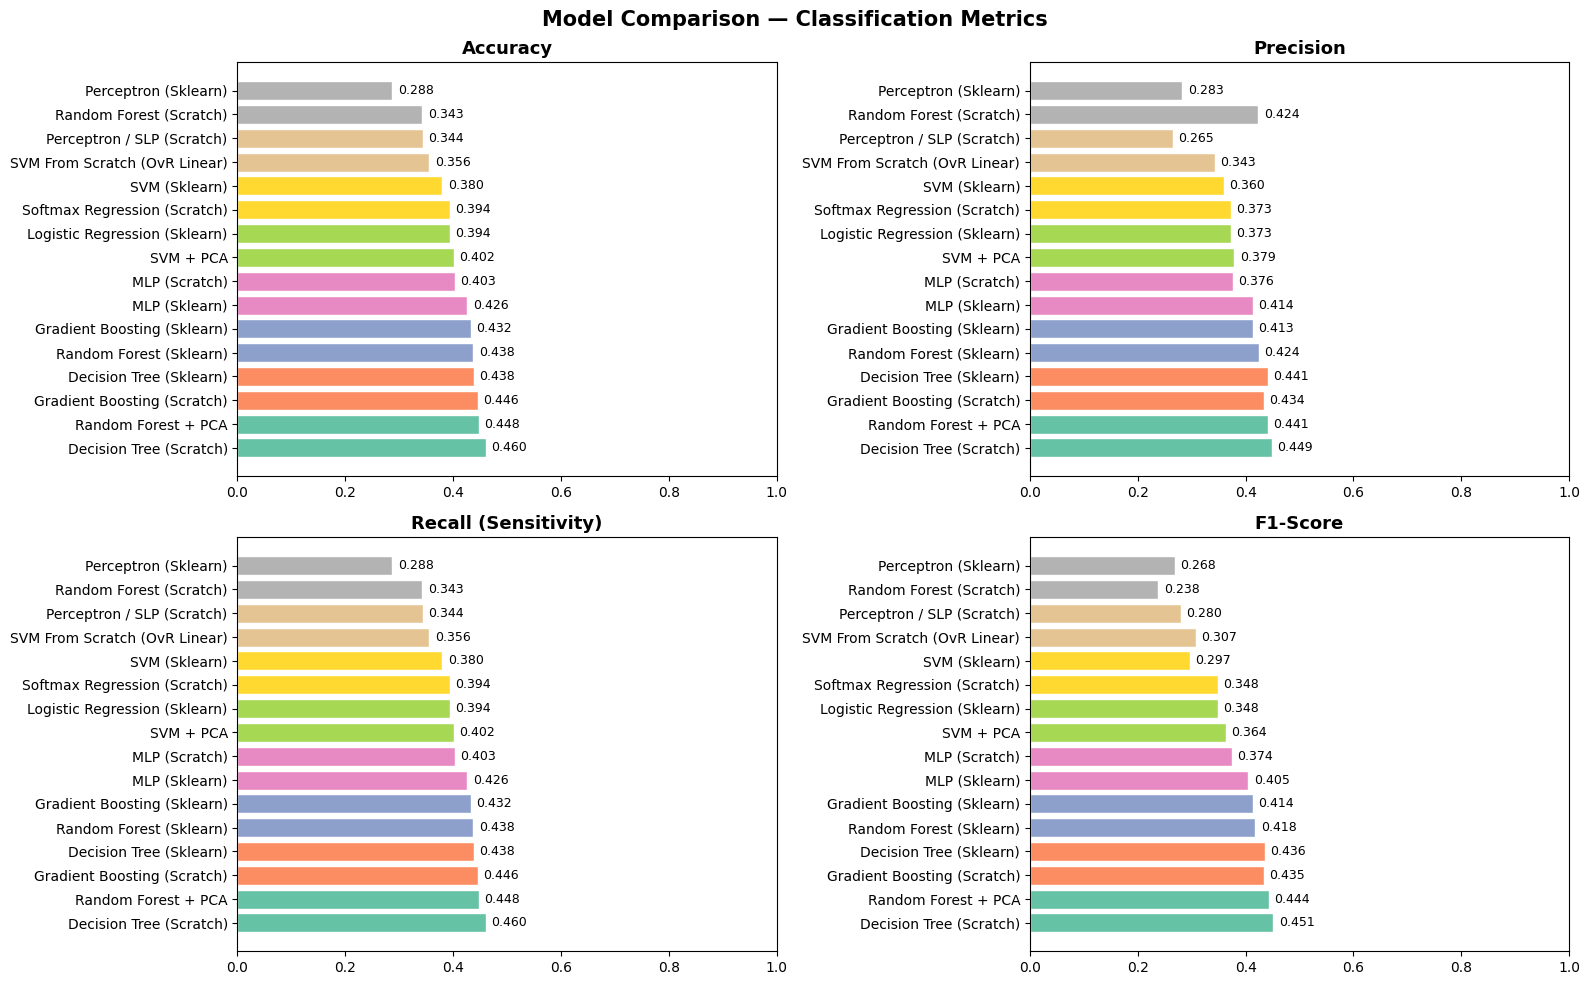

In [ ]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score']
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric].values
    bars = ax.barh(results_df.index, values, color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Classification Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

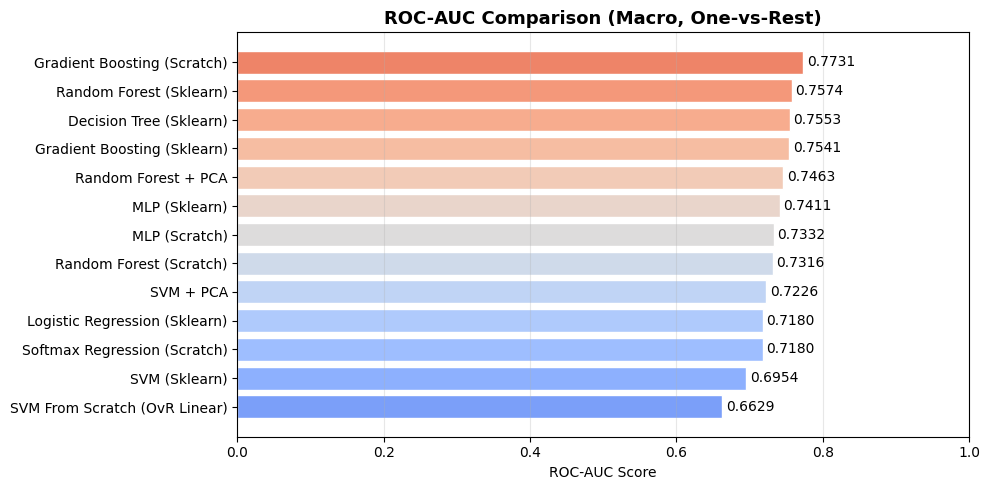

In [ ]:
# ROC-AUC comparison (only models with AUC)
auc_df = results_df.dropna(subset=['ROC-AUC']).sort_values('ROC-AUC', ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(auc_df.index, auc_df['ROC-AUC'],
                color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(auc_df))),
                edgecolor='white')
for bar, val in zip(bars, auc_df['ROC-AUC']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=10)
plt.title('ROC-AUC Comparison (Macro, One-vs-Rest)', fontsize=13, fontweight='bold')
plt.xlabel('ROC-AUC Score')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Combined ROC Curves — All Models

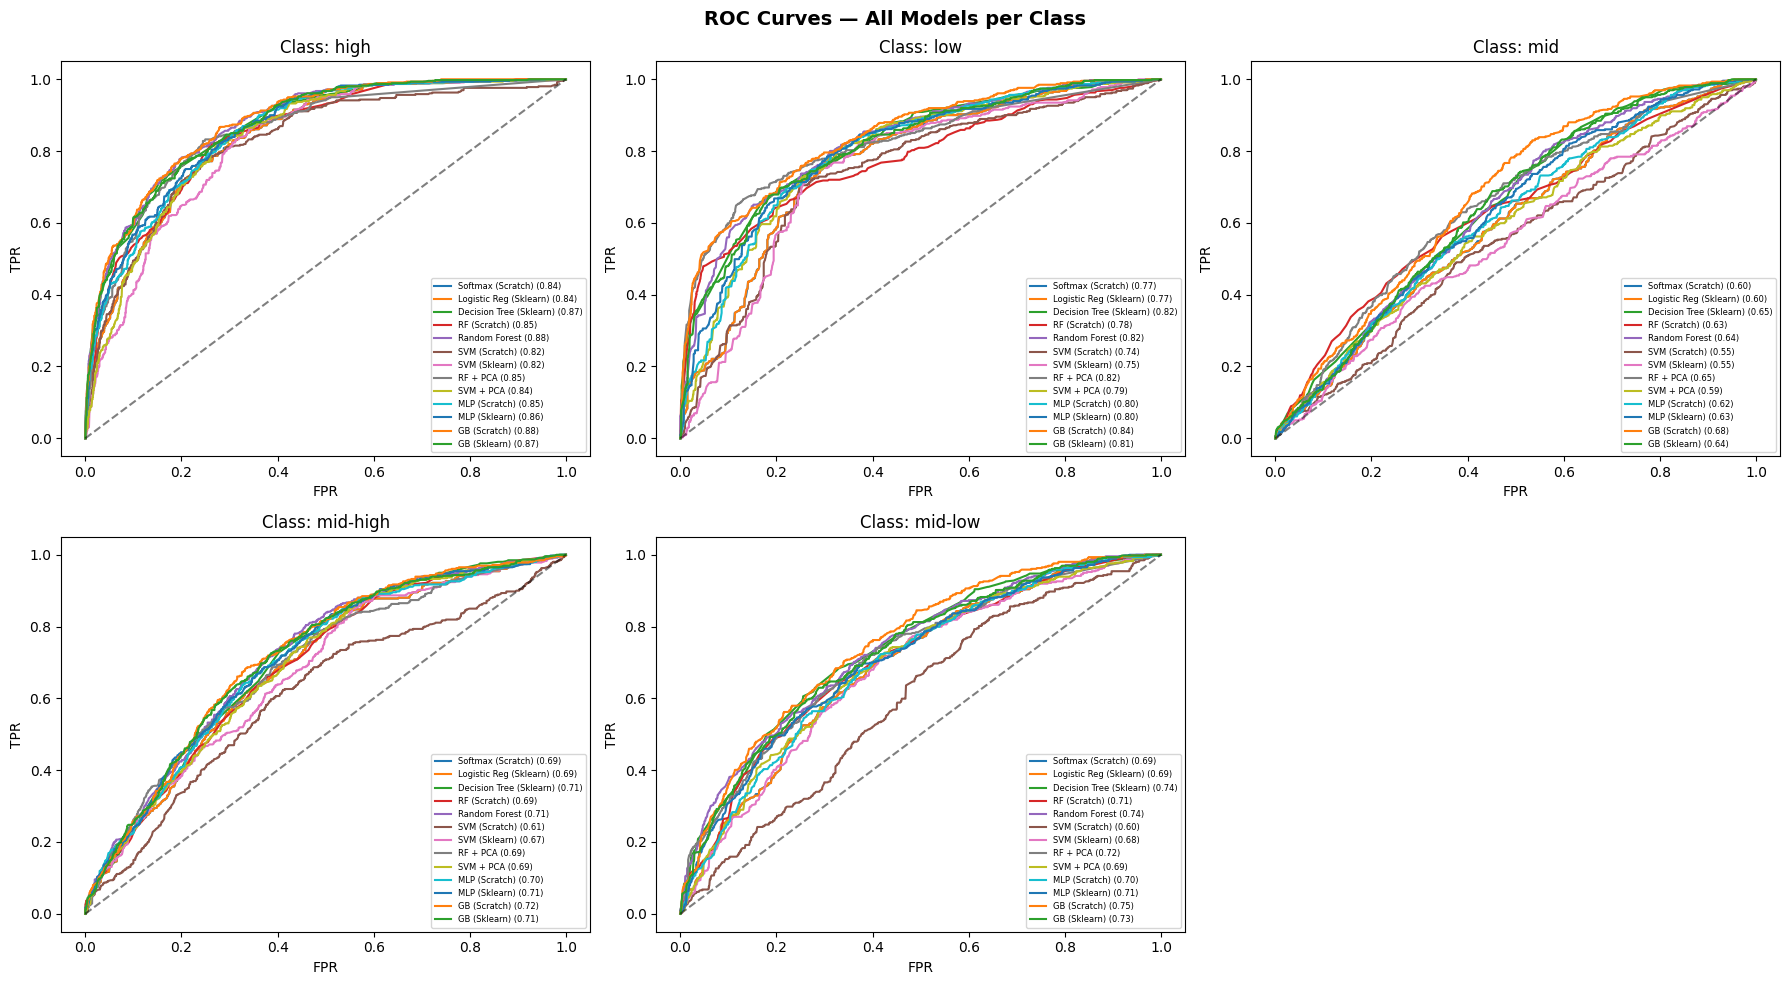

In [ ]:
# Combine ROC curves for all models with probability estimates
models_with_proba = {
    'Softmax (Scratch)': y_proba_softmax,
    'Logistic Reg (Sklearn)': y_proba_sklr,
    'Decision Tree (Sklearn)': y_proba_skdt,
    'RF (Scratch)': y_proba_rf_scratch,
    'Random Forest': y_proba_rf,
    'SVM (Scratch)': y_proba_svm_scratch,
    'SVM (Sklearn)': y_proba_svm,
    'RF + PCA': y_proba_rf_pca,
    'SVM + PCA': y_proba_svm_pca,
    'MLP (Scratch)': y_proba_mlp,
    'MLP (Sklearn)': y_proba_sk_mlp,
    'GB (Scratch)': y_proba_gb,
    'GB (Sklearn)': y_proba_sk_gb,
}

y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flat

for cls_idx in range(num_classes):
    ax = axes[cls_idx]
    for name, proba in models_with_proba.items():
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], proba[:, cls_idx])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} ({roc_auc_val:.2f})', linewidth=1.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(f'Class: {class_names[cls_idx]}', fontsize=12)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=6, loc='lower right')

# Hide the 6th subplot if only 5 classes
if num_classes < 6:
    axes[5].set_visible(False)

plt.suptitle('ROC Curves — All Models per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary & Discussion

### Key Findings:

1. **Ensemble methods** (Random Forest, Gradient Boosting) generally achieve the best accuracy and F1-scores, outperforming single models.

2. **From-scratch implementations** (Softmax Regression, Decision Tree, Perceptron, MLP, Gradient Boosting, K-Means) produce results comparable to their Sklearn counterparts, validating our implementations.

3. **Dimensionality reduction (PCA)** can sometimes improve or slightly reduce performance — it depends on whether the removed variance was noise or signal.

4. **Unsupervised clustering** (K-Means, Agglomerative) reveals natural groupings in the data, but the clusters don't perfectly align with funding levels since the target is derived from per-year distributions.

5. **MLP (Neural Network)** with a hidden layer captures non-linear patterns better than logistic regression, but may overfit without regularization.

6. **Gradient Boosting** is the extracurricular model that typically provides the best overall performance for tabular data classification tasks.

### Evaluation Metrics Summary:
- **Confusion Matrix**: Shows per-class prediction accuracy
- **ROC-AUC**: Measures discriminative ability across all thresholds
- **Precision/Recall/F1**: Balance between false positives and false negatives
- **Specificity (TNR)**: Ability to correctly identify negative cases
- **Performance Curves**: Training loss and accuracy trends over iterations

In [ ]:
# Final summary table
print("\n" + "=" * 80)
print("  FINAL MODEL RANKING")
print("=" * 80)
print(results_df.to_string())
print("\nBest model by Accuracy:", results_df.index[0],
      f"({results_df['Accuracy'].iloc[0]:.4f})")
best_auc_name = auc_df.index[-1] if len(auc_df) > 0 else 'N/A'
best_auc_val = auc_df['ROC-AUC'].iloc[-1] if len(auc_df) > 0 else 0
print(f"Best model by ROC-AUC: {best_auc_name} ({best_auc_val:.4f})")


  FINAL MODEL RANKING
                               Accuracy  Precision  Recall (Sensitivity)  Specificity (TNR)  F1-Score   ROC-AUC
Decision Tree (Scratch)        0.460200   0.449288              0.460200           0.865052  0.451428       NaN
Random Forest + PCA            0.448021   0.441189              0.448021           0.862011  0.443831  0.746282
Gradient Boosting (Scratch)    0.445846   0.433679              0.445846           0.861456  0.434502  0.773112
Decision Tree (Sklearn)        0.438452   0.441417              0.438452           0.859620  0.436128  0.755256
Random Forest (Sklearn)        0.437582   0.424450              0.437582           0.859381  0.418148  0.757447
Gradient Boosting (Sklearn)    0.432362   0.413416              0.432362           0.858080  0.413885  0.754138
MLP (Sklearn)                  0.426272   0.413883              0.426272           0.856551  0.405133  0.741088
MLP (Scratch)                  0.402784   0.376049              0.402784         